# Features exploration

In [182]:
# imports

from pathlib import Path # handling file paths

import numpy as np # numerical operations
import pandas as pd # CSV files

from scipy.signal import welch # spectral density estimation
from scipy.integrate import trapezoid # integration

import matplotlib.pyplot as plt # plotting

from tqdm.auto import tqdm # progress bars

from scipy.stats import mannwhitneyu # Mann-Whitney U test
from statsmodels.stats.multitest import multipletests # multiple comparisons correction

import mne

from matplotlib.lines import Line2D

## 1. Settings

In [183]:
# paths

OUTPUT_DIR = Path("outputs") # directory for outputs
OUTPUT_DIR.mkdir(parents=True, exist_ok=True) # create output directory if it doesn't exist
FIGURES_DIR = OUTPUT_DIR / "figures"
TABS_DIR = OUTPUT_DIR / "tabs"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABS_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = OUTPUT_DIR / "eeg_features_data.csv" 

print("Features file exists:", FEATURES_PATH.exists())

# EEG channels, frequency bands and regions
EEG_CHANNELS = [
    "Fp1", "Fp2", "F3", "F4",
    "C3", "C4",
    "P3", "P4",
    "O1", "O2",
    "F7", "F8",
    "T7", "T8",
    "P7", "P8",
    "Fz", "Cz", "Pz"
]


Features file exists: True


In [184]:
# function to save figures and tabs

def save_figure(filename, dpi=300):
    """
    Save the current matplotlib figure inside outputs/figures.
    """
    output_path = FIGURES_DIR / filename
    plt.savefig(output_path, dpi=dpi, bbox_inches="tight")
    print("Figure saved to:", output_path)

def save_table(df, filename, index=False):
    """
    Save a pandas DataFrame inside outputs/tabs.
    """
    output_path = TABS_DIR / filename
    df.to_csv(output_path, index=index)
    print("Table saved to:", output_path)

In [185]:
# pretty names for plots

FEATURE_LABELS = {
    "frontal_theta_power_mean": "Frontal - " r"${\theta}$ power",
    "frontal_beta_power_mean": "Frontal - " r"${\beta}$ power",
    "frontal_theta_beta_ratio": "Frontal - " r"${\theta}/{\beta}$ ratio",
    "occipital_beta_power_mean": "Occipital - " r"${\beta}$ power",
    "temporal_theta_beta_ratio": "Temporal - " r"${\theta}/{\beta}$ ratio",
    "occipital_theta_beta_ratio": "Occipital - " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_beta_ratio": "Parietal - " r"${\theta}/{\beta}$ ratio",
    "central_theta_beta_ratio": "Central - " r"${\theta}/{\beta}$ ratio",
    "T7_theta_beta_ratio": "T7 - " r"${\theta}/{\beta}$ ratio",
    "P7_theta_beta_ratio": "P7 - " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz - " r"${\theta}/{\beta}$ ratio",
    "O1_theta_beta_ratio": "O1 - " r"${\theta}/{\beta}$ ratio",
    "F4_theta_beta_ratio": "F4 - " r"${\theta}/{\beta}$ ratio",
    "temporal_theta_power_mean": "Temporal - " r"${\theta}$ power",
    "temporal_beta_power_mean": "Temporal - " r"${\beta}$ power",
    "occipital_theta_power_mean": "Occipital - " r"${\theta}$ power",
    "parietal_theta_power_mean": "Parietal - " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal - " r"${\beta}$ power",
    "parietal_theta_beta_ratio": "Parietal - " r"${\theta}/{\beta}$ ratio",
    "parietal_theta_power_mean": "Parietal - " r"${\theta}$ power",
    "parietal_beta_power_mean": "Parietal - " r"${\beta}$ power",
    "parietal_delta_power_mean": "Parietal - " r"${\delta}$ power",
    "Pz_theta_power_mean": "Pz - " r"${\theta}$ power",
    "Pz_beta_power_mean": "Pz - " r"${\beta}$ power",
    "Pz_delta_power_mean": "Pz - " r"${\delta}$ power",
    "Pz_delta_power":"Pz - " r"${\delta}$ power",
    "F4_theta_power": "F4 - " r"${\theta}$ power",
    "F4_beta_power": "F4 - " r"${\beta}$ power",
    "Fp1_theta_beta_ratio": "Fp1 - " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 - " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 - " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 - " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 - " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 - " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 - " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 - " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 - " r"${\theta}/{\beta}$ ratio",
    "F7_theta_power": "F7 - " r"${\theta}$ power",
    "F7_beta_power": "F7 - " r"${\beta}$ power",
    "F3_theta_power": "F3 - " r"${\theta}$ power",
    "F3_beta_power": "F3 - " r"${\beta}$ power",
    "C3_theta_power": "C3 - " r"${\theta}$ power",
    "C3_beta_power": "C3 - " r"${\beta}$ power",
    "P3_theta_power": "P3 - " r"${\theta}$ power",
    "P3_beta_power": "P3 - " r"${\beta}$ power",
    "T8_theta_power": "T8 - " r"${\theta}$ power",
    "T8_beta_power": "T8 - " r"${\beta}$ power",
    "F8_theta_power": "F8 - " r"${\theta}$ power",
    "F8_beta_power": "F8 - " r"${\beta}$ power",
    "O2_theta_power": "O2 - " r"${\theta}$ power",
    "O2_beta_power": "O2 - " r"${\beta}$ power",
    "C4_theta_power": "C4 - " r"${\theta}$ power",
    "C4_beta_power": "C4 - " r"${\beta}$ power",
    "Fp1_theta_power": "Fp1 - " r"${\theta}$ power",
    "Fp1_beta_power": "Fp1 - " r"${\beta}$ power",
    "Pz_theta_power": "Pz - " r"${\theta}$ power",
    "Pz_beta_power": "Pz - " r"${\beta}$ power",
    "F4_theta_beta_ratio": "F4 - " r"${\theta}/{\beta}$ ratio",
    "F7_theta_beta_ratio": "F7 - " r"${\theta}/{\beta}$ ratio",
    "F3_theta_beta_ratio": "F3 - " r"${\theta}/{\beta}$ ratio",
    "C3_theta_beta_ratio": "C3 - " r"${\theta}/{\beta}$ ratio",
    "P3_theta_beta_ratio": "P3 - " r"${\theta}/{\beta}$ ratio",
    "T8_theta_beta_ratio": "T8 - " r"${\theta}/{\beta}$ ratio",
    "F8_theta_beta_ratio": "F8 - " r"${\theta}/{\beta}$ ratio",
    "O2_theta_beta_ratio": "O2 - " r"${\theta}/{\beta}$ ratio",
    "C4_theta_beta_ratio": "C4 - " r"${\theta}/{\beta}$ ratio",
    "Fp1_theta_beta_ratio": "Fp1 - " r"${\theta}/{\beta}$ ratio",
    "Pz_theta_beta_ratio": "Pz - " r"${\theta}/{\beta}$ ratio",
    "duration_sec": "Recording duration (s)",
    "n_samples": "Number of samples",
    "id": "ID",
    "class": "Class",
    "P7_theta_beta_ratio": "P7 - " r"${\theta}/{\beta}$ ratio",
    "P7_theta_power": "P7 - " r"${\theta}$ power",
    "P7_beta_power": "P7 - " r"${\beta}$ power",
    "P7_delta_power": "P7 - " r"${\delta}$ power",
    "occipital_delta_power_mean": "Occipital - " r"${\delta}$ power",

}

# pretty name for plots
def pretty_feature_name(feature):
    """
    Return a readable name for a feature.
    If the feature is not in FEATURE_LABELS, return the original name.
    """
    return FEATURE_LABELS.get(feature, feature) 

# y-axis labels for plots
def feature_ylabel(feature):
    """
    Return an appropriate y-axis label depending on the type of feature.
    """
    if "theta_beta_ratio" in feature:
        return r"${\theta}/{\beta}$ ratio"
    elif "power" in feature:
        return "Band power"
    else:
        return "Feature value"

## 2.Preview

In [186]:
features_df = pd.read_csv(FEATURES_PATH) # load the features CSV file into a DataFrame

print("Shape:", features_df.shape) # shape
display(features_df.head()) # display first rows

Shape: (121, 124)


,ID,Class,n_samples,duration_sec,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_theta_beta_ratio,Fp2_delta_power,...,temporal_delta_power_mean,temporal_theta_power_mean,temporal_alpha_power_mean,temporal_beta_power_mean,temporal_theta_beta_ratio,occipital_delta_power_mean,occipital_theta_power_mean,occipital_alpha_power_mean,occipital_beta_power_mean,occipital_theta_beta_ratio
0,v10p,ADHD,7680,60.0,1472.907558,669.659556,608.942588,483.435006,1.385211,1909.324181,...,4693.572037,1207.565470,1373.407183,1533.081238,0.787672,3698.215641,1822.605954,1146.040417,1397.135846,1.304530
1,v12p,ADHD,7680,60.0,7226.328256,2726.162552,1050.959649,668.987877,4.075055,5349.759634,...,20712.200876,2257.740466,920.577228,600.660002,3.758766,10282.981955,3004.896965,1440.878896,1480.618304,2.029488
2,v14p,ADHD,7680,60.0,11175.990068,2243.042962,1230.887859,2600.048332,0.862693,13711.284587,...,19927.949014,3210.876579,1571.199035,2230.964801,1.439232,14610.563261,4446.438834,2352.186637,2987.891432,1.488153
3,v15p,ADHD,7680,60.0,6412.754290,959.282325,591.164081,535.863469,1.790162,8949.945201,...,8800.096107,1776.540277,1462.643774,1433.820103,1.239026,13620.186682,3002.769886,1528.235532,1335.891707,2.247764
4,v173,ADHD,7680,60.0,5075.802946,2158.031176,1858.564656,6969.494963,0.309640,4903.508953,...,1474.730803,774.847783,578.485754,1802.907919,0.429777,3670.139850,1872.638216,1305.317007,2734.878152,0.684725


In [187]:
# check

print("Class distribution:")
display(features_df["Class"].value_counts())

print("\nNumber of subjects:")
print(features_df["ID"].nunique())

print("\nMissing values:")
print(features_df.isna().sum().sum())

print("\nDuplicated IDs:")
print(features_df["ID"].duplicated().sum())

Class distribution:


Class
ADHD       61
Control    60
Name: count, dtype: int64


Number of subjects:
121

Missing values:
0

Duplicated IDs:
0


In [188]:
# separate metadata from features

# feature columns are all except "ID" and "Class"
feature_cols = [
    c for c in features_df.columns
    if c not in ["ID", "Class", "n_samples", "duration_sec"]
]


print("Number of features:", len(feature_cols))

Number of features: 120


## 3. Features exploration

In [189]:
summary = features_df[feature_cols].describe().T # summary statistics for features

OUTPUT_PATH = TABS_DIR / "1b_summary_features.csv"
summary.to_csv(OUTPUT_PATH, index=False)
summary[
    ["mean", "std", "min", "25%", "50%", "75%", "max"]
].head(122)

,mean,std,min,25%,50%,75%,max
Fp1_delta_power,9283.763667,9967.364944,863.021399,3414.678908,5196.844784,10170.698459,44294.089963
Fp1_theta_power,2376.160724,1922.367388,337.197806,1167.742902,1908.773683,2800.484404,9885.111133
Fp1_alpha_power,1172.026903,767.624859,113.905039,638.473452,1019.318698,1536.520421,5769.591562
Fp1_beta_power,1666.081242,1416.078028,162.494829,862.516023,1345.740662,1953.944432,10168.825912
Fp1_theta_beta_ratio,1.691910,0.995150,0.276612,0.984177,1.375989,2.204145,5.038881
...,...,...,...,...,...,...,...
occipital_delta_power_mean,12109.517195,13730.638126,1884.845355,4761.319521,8047.966284,12799.613684,95471.806051
occipital_theta_power_mean,3601.306903,2534.611389,868.228326,2071.399580,2950.081643,4102.289421,17643.019355
occipital_alpha_power_mean,2029.032256,1756.234521,673.196963,1257.274900,1626.478512,2148.266246,16650.960290
occipital_beta_power_mean,2474.058400,2322.672123,612.471684,1390.111297,1770.016160,2741.279262,15874.015434


### 3a. Group comparison between ADHD and Control subjects


To investigate whether the extracted EEG features differ between ADHD and Control subjects, each feature was compared between the two groups.

Since EEG-derived features may not follow a normal distribution and may contain outliers, a non-parametric statistical test was used. Specifically, the Mann-Whitney U test was applied independently to each feature.

The Mann-Whitney U test compares two independent groups without assuming that the data are normally distributed. 

For each feature, the null hypothesis is that the ADHD and Control groups come from the same distribution. In other words, under the null hypothesis, the values of that feature are not systematically higher or lower in one group compared with the other.

Unlike a t-test, which directly compares group means, the Mann-Whitney U test is based on ranks. This means that all values from both groups are first pooled together and sorted from the smallest to the largest. Each value is then assigned a rank, which represents its position in the ordered list.

For example, the smallest value receives rank 1, the second smallest value receives rank 2, and so on. Therefore, low ranks correspond to low feature values, while high ranks correspond to high feature values.

The test then evaluates whether one group tends to have systematically higher or lower ranks than the other. If ADHD subjects tend to have lower ranks than Control subjects, this means that the feature tends to have lower values in ADHD. Conversely, if ADHD subjects tend to have higher ranks, the feature tends to have higher values in ADHD.

The Mann-Whitney U statistic can be written as:

$
U_1 = R_1 - \frac{n_1(n_1+1)}{2}
$

where $R_1$ is the sum of the ranks in group 1 and $n_1$ is the number of observations in group 1. In this project, group 1 can be interpreted as the ADHD group.

The p-value obtained from the test indicates whether the difference in ranks between ADHD and Control subjects is statistically significant for that feature.

### 3b. Effect size: Cohen's d

In addition to statistical significance, the magnitude of the difference between ADHD and Control subjects was quantified using Cohen's d.

While the p-value indicates whether a difference is statistically significant, Cohen's d describes how large the difference is. This is important because a statistically significant result is not necessarily a large or meaningful difference.

Cohen's d was computed as:

$
d = \frac{\mu_{ADHD} - \mu_{Control}}{s_{pooled}}
$

where $\mu_{ADHD}$ is the mean value of the feature in the ADHD group, $\mu_{Control}$ is the mean value of the feature in the Control group, and $s_{pooled}$ is the pooled standard deviation.

The pooled standard is defined as:

$
s_{pooled} =\sqrt{\frac{s_{ADHD}^{2} + s_{Control}^{2}}{2}}
$

where $s_{ADHD}$ and $s_{Control}$ are the standard deviations of the feature in the ADHD and Control groups.

A positive Cohen's d indicates that the feature has higher average values in ADHD subjects, whereas a negative Cohen's d indicates that the feature has higher average values in Control subjects.

The absolute value of Cohen's d, $|d|$, was used to rank the features according to the strength of the group difference

A larger absolute value indicates a stronger difference between the two groups.


### 3c. Multiple comparisons correction: False Discovery Rate

Because many EEG features were tested, correction for multiple comparisons was necessary.

If only one statistical test is performed, a p-value threshold such as $p < 0.05$ is usually interpreted as a 5% risk of false positive. However, when many features are tested at the same time, the probability of obtaining significant results by chance increases.

For this reason, the p-values were corrected using the Benjamini-Hochberg False Discovery Rate procedure.

The False Discovery Rate controls the expected proportion of false discoveries among the features declared significant. In other words, it reduces the risk of interpreting random differences as meaningful results when many statistical tests are performed.

The Benjamini-Hochberg procedure works by sorting the p-values from smallest to largest:

$$
p_{(1)} \leq p_{(2)} \leq ... \leq p_{(m)}
$$

where $m$ is the total number of statistical tests.

Each ordered p-value is compared with a threshold:

$$
\frac{i}{m}Q
$$

where $i$ is the rank of the p-value, $m$ is the number of tested features, and $Q$ is the chosen false discovery rate level, usually $0.05$.

In this analysis, the FDR-corrected p-value is reported as:

$$
p_{FDR}
$$

Features with:

$$
p_{FDR} < 0.05
$$

were considered statistically significant after correction for multiple comparisons.

Therefore, Cohen's d and FDR-corrected p-values provide complementary information. Cohen's d identifies the features with the largest ADHD-Control differences, while FDR correction identifies the most statistically robust differences.


In [190]:
comparison_results = []

for feature in feature_cols:

    # ADHD group values for the feature
    adhd = features_df.loc[
        features_df["Class"] == "ADHD",
        feature
    ]

    # control group values for the feature
    control = features_df.loc[
        features_df["Class"] == "Control",
        feature
    ]

    # Mann-Whitney U test
    stat, p_value = mannwhitneyu(
        adhd,
        control,
        alternative="two-sided" # test for difference in either direction
    )

    # Cohen's d effect size
    pooled_std = np.sqrt(
        ((adhd.std() ** 2) + (control.std() ** 2)) / 2
    )

    cohen_d = (adhd.mean() - control.mean()) / pooled_std

    # store results
    comparison_results.append({
        "feature": feature,
        "ADHD_mean": adhd.mean(),
        "Control_mean": control.mean(),
        "ADHD_median": adhd.median(),
        "Control_median": control.median(),
        "p_value": p_value,
        "cohen_d": cohen_d,
        "abs_effect_size": abs(cohen_d)
    })

# DataFrame of results for all features
all_results_df = pd.DataFrame(comparison_results)


# FDR correction for multiple comparisons
all_results_df["p_fdr"] = multipletests(
    all_results_df["p_value"],
    method="fdr_bh"
)[1]

# Sort by absolute effect size
all_results_df = all_results_df.sort_values(
    "abs_effect_size",
    ascending=False
).reset_index(drop=True)

# Save full statistical comparison table
save_table(
    all_results_df,
    "1b_all_features_group_comparison.csv"
)

# Top 10 features according to Cohen's d
top10_cohen_df = all_results_df.head(10).copy()

save_table(
    top10_cohen_df,
    "1b_top10_cohen_features.csv"
)

display(top10_cohen_df)
display(all_results_df.head(20))

Table saved to: outputs\tabs\1b_all_features_group_comparison.csv
Table saved to: outputs\tabs\1b_top10_cohen_features.csv


,feature,ADHD_mean,Control_mean,ADHD_median,Control_median,p_value,cohen_d,abs_effect_size,p_fdr
0,F4_theta_beta_ratio,1.604874,2.514285,1.446785,2.318107,0.000126,-0.855814,0.855814,0.015153
1,temporal_theta_beta_ratio,1.521780,2.282167,1.419436,2.179120,0.000866,-0.733758,0.733758,0.051966
2,T7_theta_beta_ratio,1.740388,2.641041,1.586815,2.112067,0.005079,-0.636720,0.636720,0.121894
3,T8_theta_beta_ratio,1.441972,2.101792,1.300862,1.683634,0.005079,-0.604030,0.604030,0.121894
4,P4_theta_beta_ratio,2.039070,2.775912,1.918976,2.444985,0.020916,-0.574187,0.574187,0.167327
5,Pz_theta_power,2343.485518,3495.448705,1952.070856,2749.504154,0.037874,-0.555925,0.555925,0.186118
6,P7_theta_power,1866.643658,3010.952108,1646.693075,2220.048088,0.004391,-0.529347,0.529347,0.121894
7,parietal_theta_power_mean,2214.855453,3297.851935,1965.609947,2308.758275,0.063839,-0.489629,0.489629,0.247119
8,frontal_theta_beta_ratio,1.754771,2.200298,1.665834,2.227584,0.032482,-0.476417,0.476417,0.177176
9,F7_delta_power,9203.835400,14945.199284,6359.658164,8413.098621,0.095579,-0.457635,0.457635,0.297276


,feature,ADHD_mean,Control_mean,ADHD_median,Control_median,p_value,cohen_d,abs_effect_size,p_fdr
0,F4_theta_beta_ratio,1.604874,2.514285,1.446785,2.318107,0.000126,-0.855814,0.855814,0.015153
1,temporal_theta_beta_ratio,1.521780,2.282167,1.419436,2.179120,0.000866,-0.733758,0.733758,0.051966
2,T7_theta_beta_ratio,1.740388,2.641041,1.586815,2.112067,0.005079,-0.636720,0.636720,0.121894
3,T8_theta_beta_ratio,1.441972,2.101792,1.300862,1.683634,0.005079,-0.604030,0.604030,0.121894
4,P4_theta_beta_ratio,2.039070,2.775912,1.918976,2.444985,0.020916,-0.574187,0.574187,0.167327
5,Pz_theta_power,2343.485518,3495.448705,1952.070856,2749.504154,0.037874,-0.555925,0.555925,0.186118
6,P7_theta_power,1866.643658,3010.952108,1646.693075,2220.048088,0.004391,-0.529347,0.529347,0.121894
7,parietal_theta_power_mean,2214.855453,3297.851935,1965.609947,2308.758275,0.063839,-0.489629,0.489629,0.247119
8,frontal_theta_beta_ratio,1.754771,2.200298,1.665834,2.227584,0.032482,-0.476417,0.476417,0.177176
9,F7_delta_power,9203.835400,14945.199284,6359.658164,8413.098621,0.095579,-0.457635,0.457635,0.297276


In [191]:
# FDR-significant features
significant_fdr_df = all_results_df[
    all_results_df["p_fdr"] < 0.05
].sort_values("p_fdr")

fdr_features = significant_fdr_df["feature"].tolist()

save_table(
    significant_fdr_df,
    "1b_fdr_significant_features.csv"
)

print("Number of FDR-significant features:", len(fdr_features))
print("FDR-significant features:")
print(fdr_features)

display(significant_fdr_df)

Table saved to: outputs\tabs\1b_fdr_significant_features.csv
Number of FDR-significant features: 1
FDR-significant features:
['F4_theta_beta_ratio']


,feature,ADHD_mean,Control_mean,ADHD_median,Control_median,p_value,cohen_d,abs_effect_size,p_fdr
0,F4_theta_beta_ratio,1.604874,2.514285,1.446785,2.318107,0.000126,-0.855814,0.855814,0.015153


In [192]:
# Top 10 features according to Cohen's d
top_cohen_features = all_results_df.head(10)["feature"].tolist()

# print("Top features by Cohen's d:")
# print(top_cohen_features)

Figure saved to: outputs\figures\1b_TOP_features_by_Cohensd.png


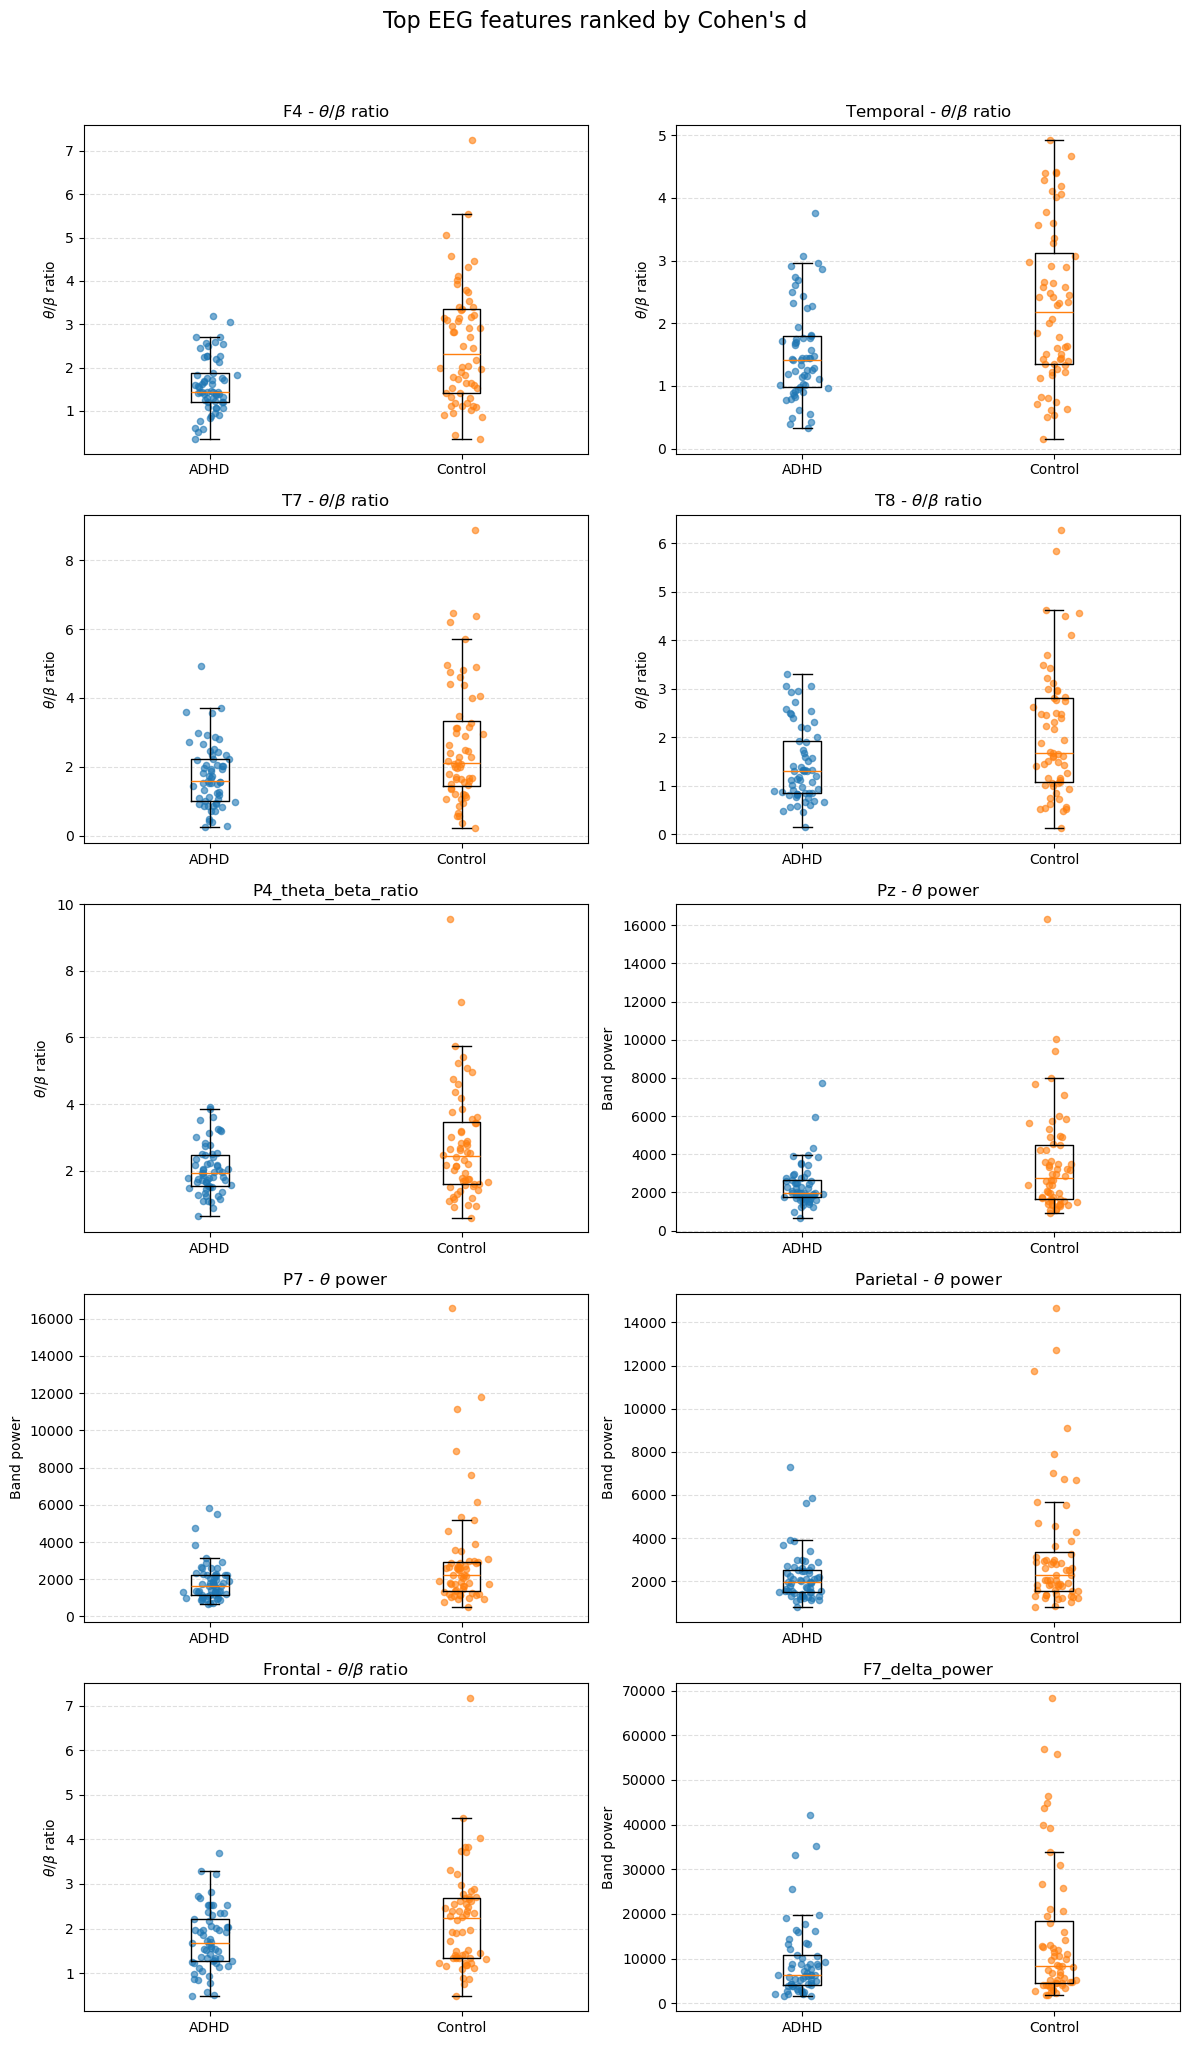

In [193]:
n_features = len(top_cohen_features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols)) # calculate number of rows needed for 2 columns

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

fig.suptitle(
    "Top EEG features ranked by Cohen's d",
    fontsize=16,
    y=1.02
)

axes = np.array(axes).flatten() 

for ax, feature in zip(axes, top_cohen_features):

    adhd = features_df.loc[
        features_df["Class"] == "ADHD",
        feature
    ]

    control = features_df.loc[
        features_df["Class"] == "Control",
        feature
    ]

    data = [adhd, control]

    ax.boxplot(
        data,
        tick_labels=["ADHD", "Control"],
        showfliers=False
    )

    for i, values in enumerate(data, start=1):

        x = np.random.normal(
            loc=i,
            scale=0.04,
            size=len(values)
        )

        ax.scatter(
            x,
            values,
            alpha=0.6,
            s=20
        )

    ax.set_title(pretty_feature_name(feature))
    ax.set_ylabel(feature_ylabel(feature))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

for ax in axes[n_features:]:
    ax.axis("off")
plt.tight_layout()
save_figure("1b_TOP_features_by_Cohensd.png")
plt.show()

Figure saved to: outputs\figures\1b_FDR_significant_features.png


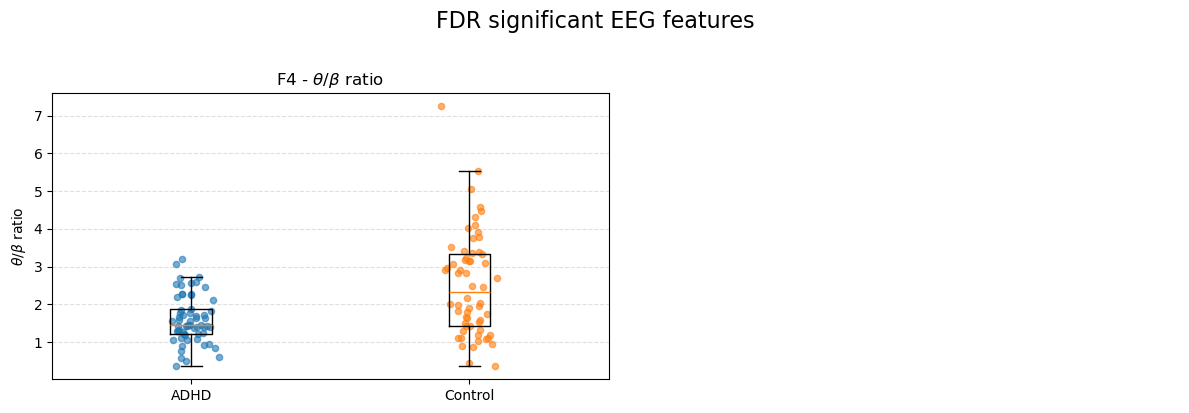

In [194]:
n_features = len(fdr_features)
n_cols = 2
n_rows = int(np.ceil(n_features / n_cols)) # calculate number of rows needed for 2 columns

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(12, 4 * n_rows)
)

fig.suptitle(
    "FDR significant EEG features",
    fontsize=16,
    y=1.02
)

axes = np.array(axes).flatten() 

for ax, feature in zip(axes, fdr_features):

    adhd = features_df.loc[
        features_df["Class"] == "ADHD",
        feature
    ]

    control = features_df.loc[
        features_df["Class"] == "Control",
        feature
    ]

    data = [adhd, control]

    ax.boxplot(
        data,
        tick_labels=["ADHD", "Control"],
        showfliers=False
    )

    for i, values in enumerate(data, start=1):

        x = np.random.normal(
            loc=i,
            scale=0.04,
            size=len(values)
        )

        ax.scatter(
            x,
            values,
            alpha=0.6,
            s=20
        )

    ax.set_title(pretty_feature_name(feature))
    ax.set_ylabel(feature_ylabel(feature))

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    ax.set_axisbelow(True)

for ax in axes[n_features:]:
    ax.axis("off")

plt.tight_layout()
save_figure("1b_FDR_significant_features.png")
plt.show()

In [195]:
# Regional effect size matrix: regions x feature types

regions = [
    "frontal",
    "central",
    "temporal",
    "parietal",
    "occipital"
]

regional_feature_types = {
    r"$\delta$ power": "delta_power_mean",
    r"$\theta$ power": "theta_power_mean",
    r"$\alpha$ power": "alpha_power_mean",
    r"$\beta$ power": "beta_power_mean",
    r"$\theta/\beta$ ratio": "theta_beta_ratio"
}

regional_cohen_matrix = pd.DataFrame(
    index=regions,
    columns=regional_feature_types.keys(),
    dtype=float
)

regional_fdr_matrix = pd.DataFrame(
    index=regions,
    columns=regional_feature_types.keys(),
    dtype=float
)

for region in regions:
    for label, suffix in regional_feature_types.items():

        feature_name = f"{region}_{suffix}"

        row = all_results_df.loc[
            all_results_df["feature"] == feature_name
        ]

        if not row.empty:
            regional_cohen_matrix.loc[region, label] = row["cohen_d"].iloc[0]
            regional_fdr_matrix.loc[region, label] = row["p_fdr"].iloc[0]

display(regional_cohen_matrix)

,$\delta$ power,$\theta$ power,$\alpha$ power,$\beta$ power,$\theta/\beta$ ratio
frontal,-0.334875,-0.278202,-0.055239,0.120201,-0.476417
central,-0.194637,-0.426880,-0.241669,-0.184657,-0.378230
temporal,-0.339578,-0.400187,-0.119262,0.229279,-0.733758
parietal,-0.334596,-0.489629,-0.277115,-0.269307,-0.229137
occipital,-0.255850,-0.368584,0.003420,0.014852,-0.404313


Figure saved to: outputs\figures\1b_regional_effect_size.png


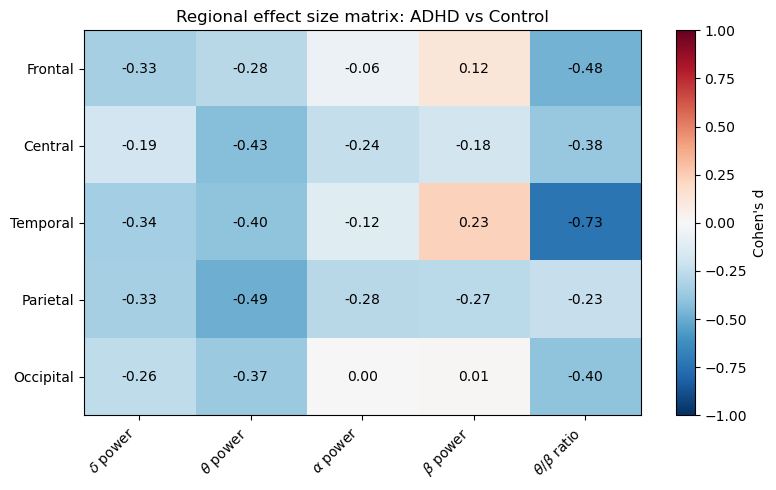

In [196]:
# Plot regional effect size matrix

plt.figure(figsize=(8, 5))

values = regional_cohen_matrix.values.astype(float)
vmax = np.nanmax(np.abs(values))

plt.imshow(
    values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Cohen's d")

plt.xticks(
    ticks=np.arange(len(regional_cohen_matrix.columns)),
    labels=regional_cohen_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(regional_cohen_matrix.index)),
    labels=[region.capitalize() for region in regional_cohen_matrix.index]
)

# Add Cohen's d values inside each cell
for i in range(regional_cohen_matrix.shape[0]):
    for j in range(regional_cohen_matrix.shape[1]):

        value = regional_cohen_matrix.iloc[i, j]
        p_fdr = regional_fdr_matrix.iloc[i, j]

        if not np.isnan(value):
            text = f"{value:.2f}"

            if p_fdr < 0.05:
                text += " *"

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=10
            )

plt.title("Regional effect size matrix: ADHD vs Control")
plt.tight_layout()
save_figure("1b_regional_effect_size.png")
plt.show()

In [197]:
# Channel-level effect size matrix: channels x feature types

channel_order = [
    "Fp1", "Fp2",
    "F7", "F3", "Fz", "F4", "F8",
    "T7", "C3", "Cz", "C4", "T8",
    "P7", "P3", "Pz", "P4", "P8",
    "O1", "O2"
]

channel_feature_types = {
    r"$\delta$ power": "delta_power",
    r"$\theta$ power": "theta_power",
    r"$\alpha$ power": "alpha_power",
    r"$\beta$ power": "beta_power",
    r"$\theta/\beta$ ratio": "theta_beta_ratio"
}

channel_cohen_matrix = pd.DataFrame(
    index=channel_order,
    columns=channel_feature_types.keys(),
    dtype=float
)

channel_fdr_matrix = pd.DataFrame(
    index=channel_order,
    columns=channel_feature_types.keys(),
    dtype=float
)

for channel in channel_order:
    for label, suffix in channel_feature_types.items():

        feature_name = f"{channel}_{suffix}"

        row = all_results_df.loc[
            all_results_df["feature"] == feature_name
        ]

        if not row.empty:
            channel_cohen_matrix.loc[channel, label] = row["cohen_d"].iloc[0]
            channel_fdr_matrix.loc[channel, label] = row["p_fdr"].iloc[0]

display(channel_cohen_matrix)

,$\delta$ power,$\theta$ power,$\alpha$ power,$\beta$ power,$\theta/\beta$ ratio
Fp1,-0.270663,-0.190914,-0.018751,-0.037653,-0.223628
Fp2,-0.041741,0.005507,0.117197,0.154607,-0.315180
F7,-0.457635,-0.451012,-0.248458,-0.115594,-0.346161
F3,-0.406117,-0.296434,-0.136741,0.003900,-0.399680
Fz,-0.404842,-0.149376,0.012791,0.186580,-0.425739
F4,-0.299880,-0.390368,-0.072289,0.253476,-0.855814
F8,-0.183214,-0.178149,-0.076613,0.137582,-0.402398
T7,-0.345027,-0.434030,-0.136085,0.142921,-0.636720
C3,-0.091669,-0.325743,-0.110223,0.017829,-0.284101
Cz,-0.409487,-0.400978,-0.266713,-0.189924,-0.192554


Figure saved to: outputs\figures\1b_Tchannel_effect_size.png


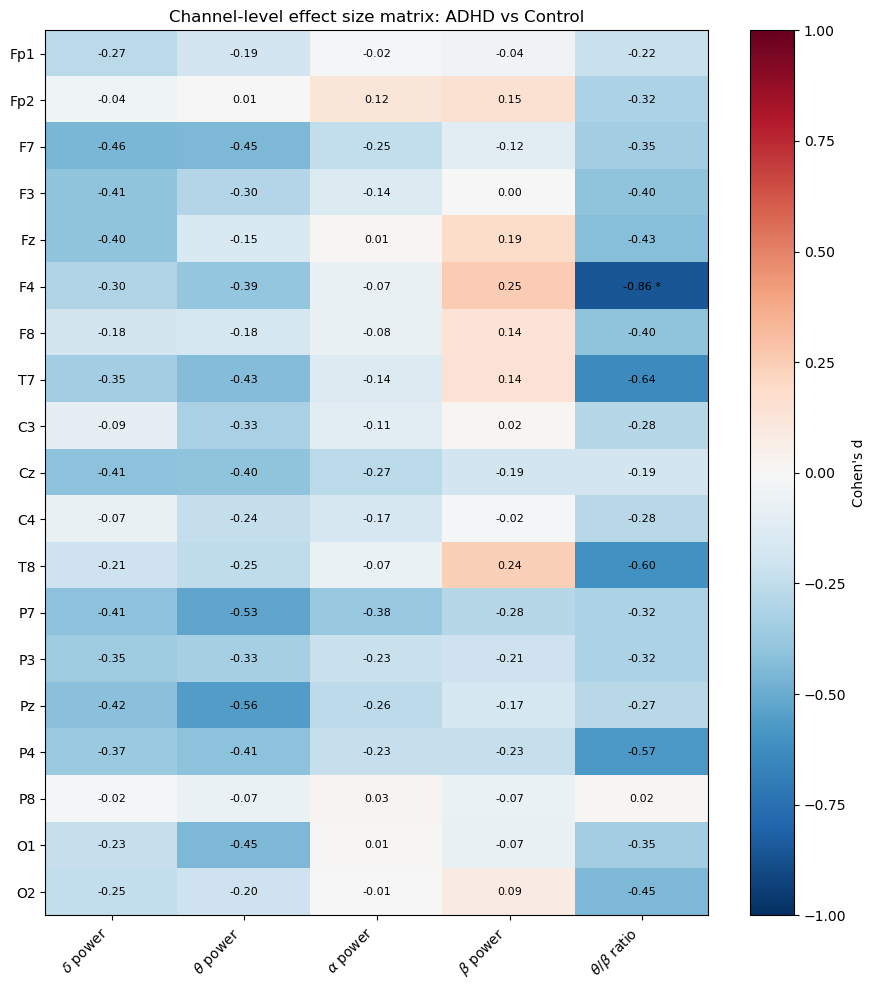

In [198]:
# Plot channel-level effect size matrix

plt.figure(figsize=(9, 10))

values = channel_cohen_matrix.values.astype(float)
vmax = np.nanmax(np.abs(values))

plt.imshow(
    values,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Cohen's d")

plt.xticks(
    ticks=np.arange(len(channel_cohen_matrix.columns)),
    labels=channel_cohen_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(channel_cohen_matrix.index)),
    labels=channel_cohen_matrix.index
)

# Add Cohen's d values inside each cell
for i in range(channel_cohen_matrix.shape[0]):
    for j in range(channel_cohen_matrix.shape[1]):

        value = channel_cohen_matrix.iloc[i, j]
        p_fdr = channel_fdr_matrix.iloc[i, j]

        if not np.isnan(value):
            text = f"{value:.2f}"

            if p_fdr < 0.05:
                text += " *"

            plt.text(
                j,
                i,
                text,
                ha="center",
                va="center",
                fontsize=8
            )

plt.title("Channel-level effect size matrix: ADHD vs Control")
plt.tight_layout()
save_figure("1b_Tchannel_effect_size.png")
plt.show()

,$\delta$ power,$\theta$ power,$\alpha$ power,$\beta$ power,$\theta/\beta$ ratio
Fp1,-0.270663,-0.190914,-0.018751,-0.037653,-0.223628
Fp2,-0.041741,0.005507,0.117197,0.154607,-0.315180
F7,-0.457635,-0.451012,-0.248458,-0.115594,-0.346161
F3,-0.406117,-0.296434,-0.136741,0.003900,-0.399680
Fz,-0.404842,-0.149376,0.012791,0.186580,-0.425739
F4,-0.299880,-0.390368,-0.072289,0.253476,-0.855814
F8,-0.183214,-0.178149,-0.076613,0.137582,-0.402398
T7,-0.345027,-0.434030,-0.136085,0.142921,-0.636720
C3,-0.091669,-0.325743,-0.110223,0.017829,-0.284101
Cz,-0.409487,-0.400978,-0.266713,-0.189924,-0.192554


,$\delta$ power,$\theta$ power,$\alpha$ power,$\beta$ power,$\theta/\beta$ ratio
Fp1,0.284137,0.586099,0.651856,0.754157,0.651856
Fp2,0.586099,0.496062,0.647685,0.766129,0.313593
F7,0.297276,0.177176,0.565139,0.766129,0.223943
F3,0.400611,0.850157,0.997932,0.766129,0.186118
Fz,0.164961,0.850157,0.754157,0.649042,0.261579
F4,0.722263,0.457146,0.997932,0.167327,0.015153
F8,0.429330,0.378421,0.850157,0.563830,0.172601
T7,0.186118,0.265833,0.586099,0.806930,0.121894
C3,0.400611,0.484612,0.930404,0.856347,0.167327
Cz,0.200580,0.185433,0.850157,0.766129,0.164961


Figure saved to: outputs\figures\1b_channel_effect_size_topomaps.png


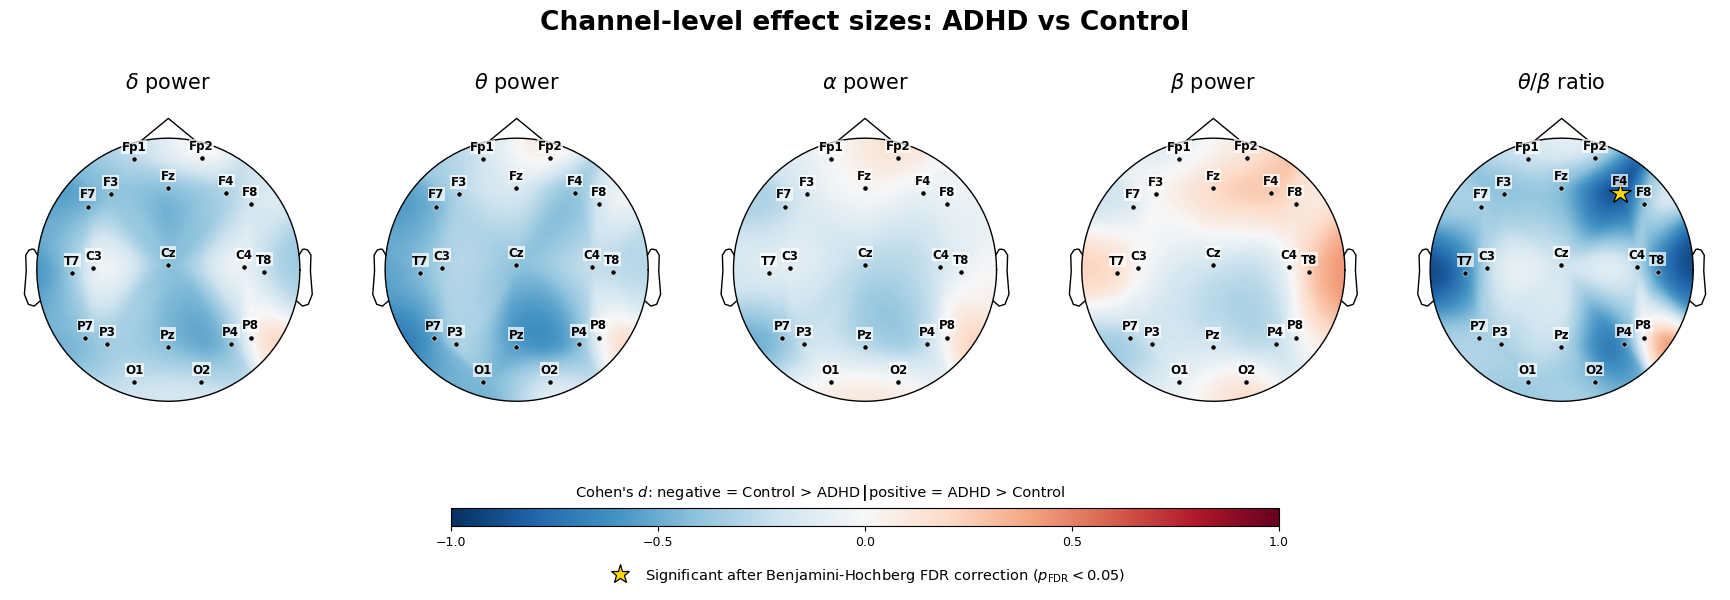

In [199]:
# ============================================================
# CHANNEL-LEVEL EFFECT SIZES:
# FIVE TOPOGRAPHIC MAPS WITH FDR-SIGNIFICANT CHANNELS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

from matplotlib.lines import Line2D


# ------------------------------------------------------------
# 1. Channel order and feature types
# ------------------------------------------------------------

channel_order = [
    "Fp1", "Fp2",
    "F7", "F3", "Fz", "F4", "F8",
    "T7", "C3", "Cz", "C4", "T8",
    "P7", "P3", "Pz", "P4", "P8",
    "O1", "O2"
]

channel_feature_types = {
    r"$\delta$ power": "delta_power",
    r"$\theta$ power": "theta_power",
    r"$\alpha$ power": "alpha_power",
    r"$\beta$ power": "beta_power",
    r"$\theta/\beta$ ratio": "theta_beta_ratio"
}


# ------------------------------------------------------------
# 2. Check required columns
# ------------------------------------------------------------

required_columns = {
    "feature",
    "cohen_d",
    "p_fdr"
}

missing_columns = (
    required_columns
    - set(all_results_df.columns)
)

if missing_columns:

    raise ValueError(
        "Missing columns in all_results_df: "
        + ", ".join(sorted(missing_columns))
    )


# ------------------------------------------------------------
# 3. Build Cohen's d and FDR matrices
# ------------------------------------------------------------

channel_cohen_matrix = pd.DataFrame(
    index=channel_order,
    columns=channel_feature_types.keys(),
    dtype=float
)

channel_fdr_matrix = pd.DataFrame(
    index=channel_order,
    columns=channel_feature_types.keys(),
    dtype=float
)


for channel in channel_order:

    for feature_label, feature_suffix in (
        channel_feature_types.items()
    ):

        feature_name = (
            f"{channel}_{feature_suffix}"
        )

        feature_row = all_results_df.loc[
            all_results_df["feature"] == feature_name
        ]

        if not feature_row.empty:

            channel_cohen_matrix.loc[
                channel,
                feature_label
            ] = float(
                feature_row["cohen_d"].iloc[0]
            )

            channel_fdr_matrix.loc[
                channel,
                feature_label
            ] = float(
                feature_row["p_fdr"].iloc[0]
            )


display(channel_cohen_matrix)
display(channel_fdr_matrix)


# ------------------------------------------------------------
# 4. Check missing features
# ------------------------------------------------------------

missing_cohen = channel_cohen_matrix.isna()

if missing_cohen.any().any():

    print(
        "Warning: some channel-level effect sizes are missing:"
    )

    missing_indices = np.argwhere(
        missing_cohen.to_numpy()
    )

    for row_index, column_index in missing_indices:

        print(
            channel_cohen_matrix.index[row_index],
            "-",
            channel_cohen_matrix.columns[column_index]
        )


# ------------------------------------------------------------
# 5. Obtain channel coordinates from standard 10-20 montage
# ------------------------------------------------------------

montage = mne.channels.make_standard_montage(
    "standard_1020"
)

montage_positions = (
    montage
    .get_positions()["ch_pos"]
)


missing_position_channels = [
    channel
    for channel in channel_order
    if channel not in montage_positions
]

if missing_position_channels:

    raise ValueError(
        "Missing montage coordinates for: "
        + ", ".join(missing_position_channels)
    )


# Extract the x-y coordinates in the exact channel order
topomap_positions = np.array([
    montage_positions[channel][:2]
    for channel in channel_order
])


# Centre the coordinates
topomap_positions = (
    topomap_positions
    - topomap_positions.mean(axis=0)
)


# Scale coordinates to fit properly inside the MNE head
maximum_radius = np.max(
    np.linalg.norm(
        topomap_positions,
        axis=1
    )
)

topomap_positions = (
    topomap_positions
    / maximum_radius
    * 0.085
)


# Fixed sphere used by the topomap
TOPO_SPHERE = (
    0.0,
    0.0,
    0.0,
    0.095
)


# ------------------------------------------------------------
# 6. Plot settings
# ------------------------------------------------------------

# d < 0 -> Control > ADHD
# d > 0 -> ADHD > Control
VMAX = 1.0

SHOW_CHANNEL_NAMES = True

CHANNEL_NAME_FONT_SIZE = 8.5

# Small offset above each sensor
CHANNEL_NAME_VERTICAL_OFFSET = 0.0045


# Appearance of FDR-significant channels
mask_params = {
    "marker": "*",
    "markerfacecolor": "gold",
    "markeredgecolor": "black",
    "markeredgewidth": 0.9,
    "linewidth": 0,
    "markersize": 16
}


# ------------------------------------------------------------
# 7. Create the five topographic maps
# ------------------------------------------------------------

fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(18, 6.5),
    facecolor="white"
)

topomap_image = None


for ax, feature_label in zip(
    axes,
    channel_feature_types.keys()
):

    # Cohen's d values in channel order
    cohen_values = (
        channel_cohen_matrix
        .loc[
            channel_order,
            feature_label
        ]
        .to_numpy(dtype=float)
    )

    # FDR-adjusted p-values in channel order
    fdr_values = (
        channel_fdr_matrix
        .loc[
            channel_order,
            feature_label
        ]
        .to_numpy(dtype=float)
    )

    # Significant after FDR correction
    significant_mask = (
        np.isfinite(fdr_values)
        &
        (fdr_values < 0.05)
    )

    # Replace missing values with zero only for visualization
    plot_values = np.nan_to_num(
        cohen_values,
        nan=0.0
    )


    topomap_image, contours = mne.viz.plot_topomap(
        data=plot_values,

        # Directly use the same coordinates used for labels
        pos=topomap_positions,

        axes=ax,
        show=False,

        cmap="RdBu_r",
        vlim=(-VMAX, VMAX),

        contours=0,
        res=256,

        extrapolate="head",
        outlines="head",
        sphere=TOPO_SPHERE,

        # Sensors and names are added manually below
        sensors=False,
        names=None,

        # Significant electrodes shown as stars
        mask=significant_mask,
        mask_params=mask_params
    )


    # --------------------------------------------------------
    # Draw non-significant sensors as black dots
    # --------------------------------------------------------

    nonsignificant_mask = (
        ~significant_mask
    )

    ax.scatter(
        topomap_positions[
            nonsignificant_mask,
            0
        ],
        topomap_positions[
            nonsignificant_mask,
            1
        ],

        s=14,

        facecolor="black",
        edgecolor="white",
        linewidth=0.4,

        zorder=10
    )


    # --------------------------------------------------------
    # Add readable channel names manually
    # --------------------------------------------------------

    if SHOW_CHANNEL_NAMES:

        for channel_name, (
            position_x,
            position_y
        ) in zip(
            channel_order,
            topomap_positions
        ):

            ax.text(
                position_x,
                position_y
                + CHANNEL_NAME_VERTICAL_OFFSET,

                channel_name,

                ha="center",
                va="bottom",

                fontsize=CHANNEL_NAME_FONT_SIZE,
                fontweight="bold",
                color="black",

                bbox={
                    "facecolor": "white",
                    "edgecolor": "none",
                    "alpha": 0.70,
                    "pad": 0.25
                },

                zorder=20
            )


    ax.set_title(
        feature_label,
        fontsize=15,
        pad=12
    )


# ------------------------------------------------------------
# 8. Main title and layout
# ------------------------------------------------------------

fig.suptitle(
    "Channel-level effect sizes: ADHD vs Control",
    fontsize=19,
    fontweight="bold",
    y=0.95
)

fig.subplots_adjust(
    left=0.025,
    right=0.975,
    top=0.81,
    bottom=0.34,
    wspace=0.10
)


# ------------------------------------------------------------
# 9. Shared horizontal colorbar
# ------------------------------------------------------------

if topomap_image is None:

    raise RuntimeError(
        "No topomap was created."
    )


# Symmetric horizontal colorbar
colorbar_axis = fig.add_axes([
    0.27,   # left
    0.155,  # bottom
    0.46,   # width
    0.027   # height
])

colorbar = fig.colorbar(
    topomap_image,
    cax=colorbar_axis,
    orientation="horizontal"
)

colorbar.set_ticks([
    -1.0,
    -0.5,
    0.0,
    0.5,
    1.0
])

colorbar.ax.tick_params(
    labelsize=9,
    pad=3
)


# ------------------------------------------------------------
# Description aligned with the zero of the colorbar
# ------------------------------------------------------------

TEXT_Y = 1.90

colorbar.ax.text(
    0.495,
    TEXT_Y,
    r"Cohen's $d$: negative = Control > ADHD",
    transform=colorbar.ax.transAxes,
    ha="right",
    va="center",
    fontsize=10.5
)

colorbar.ax.text(
    0.500,
    TEXT_Y,
    "|",
    transform=colorbar.ax.transAxes,
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold"
)

colorbar.ax.text(
    0.505,
    TEXT_Y,
    r"positive = ADHD > Control",
    transform=colorbar.ax.transAxes,
    ha="left",
    va="center",
    fontsize=10.5
)


# ------------------------------------------------------------
# 10. Legend for FDR-significant channels
# ------------------------------------------------------------

fdr_star = Line2D(
    [0],
    [0],

    marker="*",
    linestyle="None",

    markerfacecolor="gold",
    markeredgecolor="black",
    markeredgewidth=0.9,

    markersize=14,

    label=(
        "Significant after Benjamini-Hochberg FDR correction "
        r"($p_{\mathrm{FDR}}<0.05$)"
    )
)

fig.legend(
    handles=[fdr_star],

    loc="lower center",

    bbox_to_anchor=(
        0.5,
        0.045
    ),

    frameon=False,
    fontsize=10.5,
    handletextpad=0.7
)


# ------------------------------------------------------------
# 11. Save and show
# ------------------------------------------------------------

save_figure(
    "1b_channel_effect_size_topomaps.png",
    dpi=300
)

plt.show()

### 3d. Correlation matrix across all EEG features

Spearman correlation was used instead of Pearson correlation because EEG-derived features may not be normally distributed and may contain outliers. Spearman correlation measures whether two variables tend to increase or decrease together in a monotonic way, based on their ranks rather than on their raw values.

The Spearman correlation coefficient ranges from -1 to 1:

$$
\rho = 1
$$

indicates a perfect positive monotonic relationship,

$$
\rho = -1
$$

indicates a perfect negative monotonic relationship, and

$$
\rho = 0
$$

indicates no monotonic relationship.

This analysis does not compare ADHD and Control subjects directly. Instead, it investigates how similar or redundant the extracted features are across all subjects.

In [200]:
# Define regional and channel-level feature columns for correlation analysis

regional_prefixes = (
    "frontal_",
    "central_",
    "temporal_",
    "parietal_",
    "occipital_"
)

metadata_cols = [
    "ID",
    "Class",
    "n_samples",
    "duration_sec"
]

eeg_feature_cols = [
    c for c in features_df.columns
    if c not in metadata_cols
]

eeg_feature_cols = [
    c for c in eeg_feature_cols
    if pd.api.types.is_numeric_dtype(features_df[c])
]

regional_corr_features = [
    c for c in eeg_feature_cols
    if c.startswith(regional_prefixes)
]

channel_corr_features = [
    c for c in eeg_feature_cols
    if not c.startswith(regional_prefixes)
]

print("Regional features:", len(regional_corr_features))
print("Channel-level features:", len(channel_corr_features))

Regional features: 25
Channel-level features: 95


In [201]:
def correlation_pairs_from_matrix(corr_matrix, group_label, feature_subset):
    """
    Convert a correlation matrix into a table of unique feature-feature pairs.
    """

    pairs = []
    cols = corr_matrix.columns

    for i, feature_1 in enumerate(cols):
        for j, feature_2 in enumerate(cols):

            if j <= i:
                continue

            corr_value = corr_matrix.loc[feature_1, feature_2]

            pairs.append({
                "group": group_label,
                "feature_subset": feature_subset,
                "feature_1": feature_1,
                "feature_2": feature_2,
                "spearman_r": corr_value,
                "abs_spearman_r": abs(corr_value)
            })

    return pd.DataFrame(pairs)

# Plot full correlation matrix with feature names
def short_feature_name(feature):
    """
    Create shorter labels for correlation matrix axes.
    """
    name = feature

    name = name.replace("_power_mean", "")
    name = name.replace("_power", "")
    name = name.replace("_theta_beta_ratio", "_θ/β")

    name = name.replace("delta", "δ")
    name = name.replace("theta", "θ")
    name = name.replace("alpha", "α")
    name = name.replace("beta", "β")

    name = name.replace("_", " ")

    return name

In [202]:
group_corr_matrices = {}
group_corr_pairs = []

for group_label in ["ADHD", "Control"]:

    group_df = features_df[
        features_df["Class"] == group_label
    ].copy()

    # Regional features correlation matrix
    regional_corr = group_df[regional_corr_features].corr(
        method="spearman"
    )

    # Channel-level features correlation matrix
    channel_corr = group_df[channel_corr_features].corr(
        method="spearman"
    )

    group_corr_matrices[(group_label, "regional")] = regional_corr
    group_corr_matrices[(group_label, "channel")] = channel_corr

    # Save matrices
    save_table(
        regional_corr,
        f"1b_spearman_regional_features_{group_label}.csv",
        index=True
    )

    save_table(
        channel_corr,
        f"1b_spearman_channel_features_{group_label}.csv",
        index=True
    )

    # Convert matrices to pairwise tables
    regional_pairs = correlation_pairs_from_matrix(
        regional_corr,
        group_label,
        "regional"
    )

    channel_pairs = correlation_pairs_from_matrix(
        channel_corr,
        group_label,
        "channel"
    )

    group_corr_pairs.append(regional_pairs)
    group_corr_pairs.append(channel_pairs)

group_corr_pairs_df = pd.concat(
    group_corr_pairs,
    ignore_index=True
)

save_table(
    group_corr_pairs_df,
    "1b_group_specific_spearman_correlation_pairs.csv"
)

display(group_corr_pairs_df.head())

Table saved to: outputs\tabs\1b_spearman_regional_features_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_channel_features_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_regional_features_Control.csv
Table saved to: outputs\tabs\1b_spearman_channel_features_Control.csv
Table saved to: outputs\tabs\1b_group_specific_spearman_correlation_pairs.csv


,group,feature_subset,feature_1,feature_2,spearman_r,abs_spearman_r
0,ADHD,regional,frontal_delta_power_mean,frontal_theta_power_mean,0.699736,0.699736
1,ADHD,regional,frontal_delta_power_mean,frontal_alpha_power_mean,0.281967,0.281967
2,ADHD,regional,frontal_delta_power_mean,frontal_beta_power_mean,0.425595,0.425595
3,ADHD,regional,frontal_delta_power_mean,frontal_theta_beta_ratio,0.320994,0.320994
4,ADHD,regional,frontal_delta_power_mean,central_delta_power_mean,0.696774,0.696774


In [203]:
# Top 10 strongest channel-level correlations by absolute value, by group

channel_pairs_df = group_corr_pairs_df[
    group_corr_pairs_df["feature_subset"] == "channel"
].copy()

top_abs_channel_corr_tables = []

for group_label in ["ADHD", "Control"]:

    group_channel_pairs = channel_pairs_df[
        channel_pairs_df["group"] == group_label
    ].copy()

    top_abs = group_channel_pairs.sort_values(
        "abs_spearman_r",
        ascending=False
    ).head(10)

    top_abs_channel_corr_tables.append(top_abs)

top_abs_channel_correlations_df = pd.concat(
    top_abs_channel_corr_tables,
    ignore_index=True
)

save_table(
    top_abs_channel_correlations_df,
    "1b_top_abs_channel_correlations_by_group.csv"
)

display(top_abs_channel_correlations_df)

Table saved to: outputs\tabs\1b_top_abs_channel_correlations_by_group.csv


,group,feature_subset,feature_1,feature_2,spearman_r,abs_spearman_r
0,ADHD,channel,F3_beta_power,Fz_beta_power,0.898942,0.898942
1,ADHD,channel,F4_alpha_power,Fz_alpha_power,0.877314,0.877314
2,ADHD,channel,F4_beta_power,Fz_beta_power,0.872343,0.872343
3,ADHD,channel,F3_alpha_power,F4_alpha_power,0.870756,0.870756
4,ADHD,channel,F3_beta_power,F4_beta_power,0.861555,0.861555
5,ADHD,channel,P3_alpha_power,P4_alpha_power,0.856795,0.856795
6,ADHD,channel,F3_alpha_power,Fz_alpha_power,0.851560,0.851560
7,ADHD,channel,P8_delta_power,P8_theta_power,0.850132,0.850132
8,ADHD,channel,F8_delta_power,F8_theta_power,0.849815,0.849815
9,ADHD,channel,P3_beta_power,P4_beta_power,0.849339,0.849339


In [204]:
for group_label in ["ADHD", "Control"]:

    group_channel_pairs = channel_pairs_df[
        channel_pairs_df["group"] == group_label
    ].copy()

    top_positive = group_channel_pairs.sort_values(
        "spearman_r",
        ascending=False
    ).head(10)

    top_negative = group_channel_pairs.sort_values(
        "spearman_r",
        ascending=True
    ).head(10)

    save_table(
        top_positive,
        f"1b_top_positive_channel_correlations_{group_label}.csv"
    )

    save_table(
        top_negative,
        f"1b_top_negative_channel_correlations_{group_label}.csv"
    )

Table saved to: outputs\tabs\1b_top_positive_channel_correlations_ADHD.csv
Table saved to: outputs\tabs\1b_top_negative_channel_correlations_ADHD.csv
Table saved to: outputs\tabs\1b_top_positive_channel_correlations_Control.csv
Table saved to: outputs\tabs\1b_top_negative_channel_correlations_Control.csv


In [205]:
def plot_two_group_correlation_matrices(
    corr_adhd,
    corr_control,
    title,
    filename,
    label_fontsize=6
):
    """
    Plot ADHD and Control correlation matrices side by side.
    """

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 7)
    )

    matrices = [
        ("ADHD", corr_adhd),
        ("Control", corr_control)
    ]

    for ax, (group_label, corr_matrix) in zip(axes, matrices):

        im = ax.imshow(
            corr_matrix.values,
            vmin=-1,
            vmax=1,
            aspect="auto"
        )

        labels = [
            short_feature_name(feature)
            for feature in corr_matrix.columns
        ]

        ax.set_xticks(np.arange(len(labels)))
        ax.set_yticks(np.arange(len(labels)))

        ax.set_xticklabels(
            labels,
            rotation=90,
            fontsize=label_fontsize
        )

        ax.set_yticklabels(
            labels,
            fontsize=label_fontsize
        )

        ax.set_title(group_label)

    fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        shrink=0.8,
        label="Spearman correlation"
    )

    fig.suptitle(
        title,
        fontsize=16,
        y=1.02
    )

    save_figure(filename)
    plt.show()

Figure saved to: outputs\figures\1b_regional_correlation_matrix_by_group.png


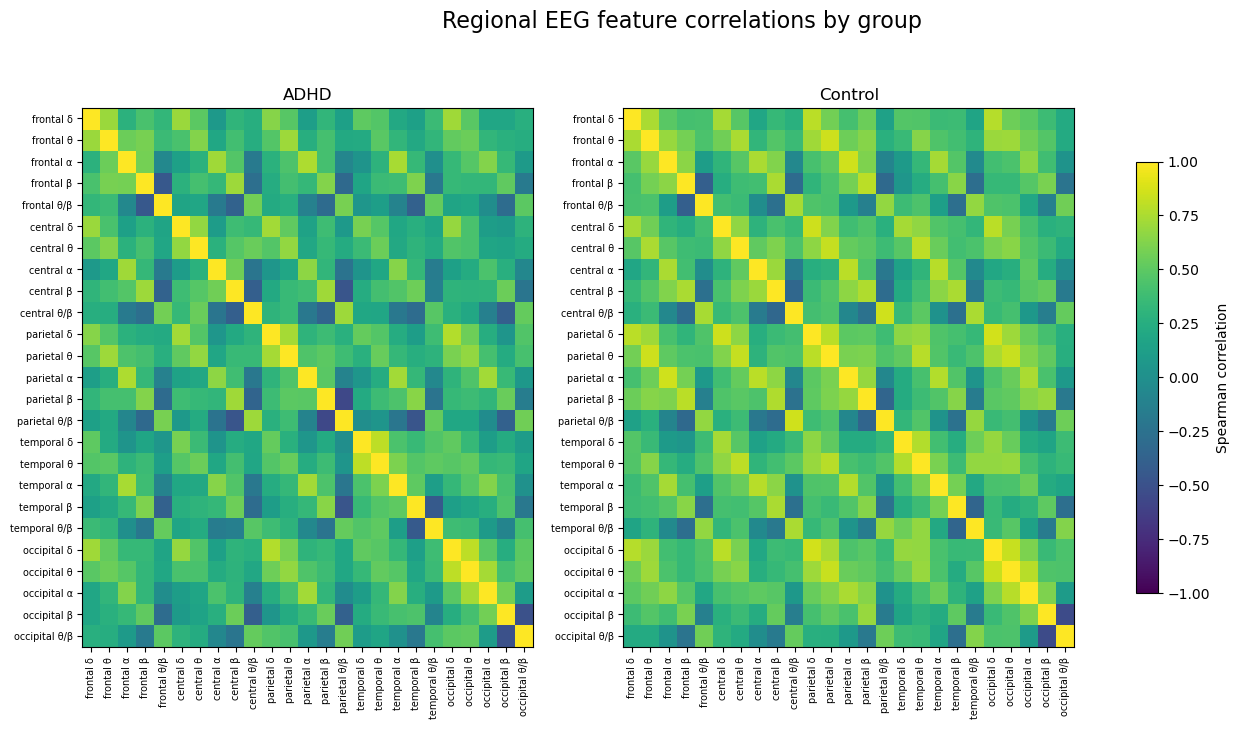

In [206]:
regional_corr_adhd = group_corr_matrices[("ADHD", "regional")]
regional_corr_control = group_corr_matrices[("Control", "regional")]

plot_two_group_correlation_matrices(
    regional_corr_adhd,
    regional_corr_control,
    title="Regional EEG feature correlations by group",
    filename="1b_regional_correlation_matrix_by_group.png",
    label_fontsize=7
)

In [207]:
def plot_correlation_distribution_by_group(
    pairs_df,
    feature_subset,
    title,
    filename
):
    """
    Plot distribution of pairwise Spearman correlations
    separately for ADHD and Control.
    """

    plt.figure(figsize=(8, 5))

    bins = np.linspace(-1, 1, 41)

    colors = {
        "ADHD": "salmon",
        "Control": "skyblue"
    }

    for group_label in ["ADHD", "Control"]:

        values = pairs_df[
            (pairs_df["group"] == group_label)
            &
            (pairs_df["feature_subset"] == feature_subset)
        ]["spearman_r"].dropna()

        plt.hist(
            values,
            bins=bins,
            alpha=0.55,
            density=True,
            label=f"{group_label} (n={len(values)})",
            color=colors[group_label]
        )

    plt.axvline(
        0,
        linestyle="--",
        color="black",
        linewidth=1
    )

    plt.xlabel("Spearman correlation")
    plt.ylabel("Density")
    plt.title(title)

    plt.legend()

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.4
    )

    plt.tight_layout()
    save_figure(filename)
    plt.show()

Figure saved to: outputs\figures\1b_regional_correlation_distribution_by_group.png


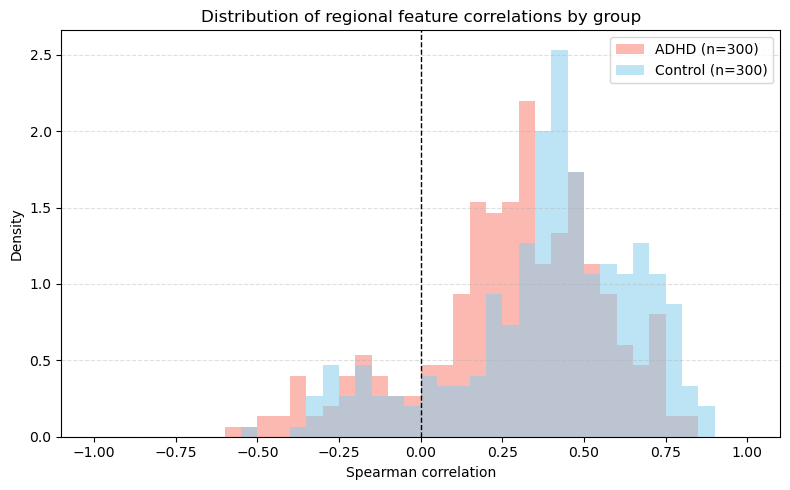

In [208]:
plot_correlation_distribution_by_group(
    group_corr_pairs_df,
    feature_subset="regional",
    title="Distribution of regional feature correlations by group",
    filename="1b_regional_correlation_distribution_by_group.png"
)

Figure saved to: outputs\figures\1b_channel_correlation_distribution_by_group.png


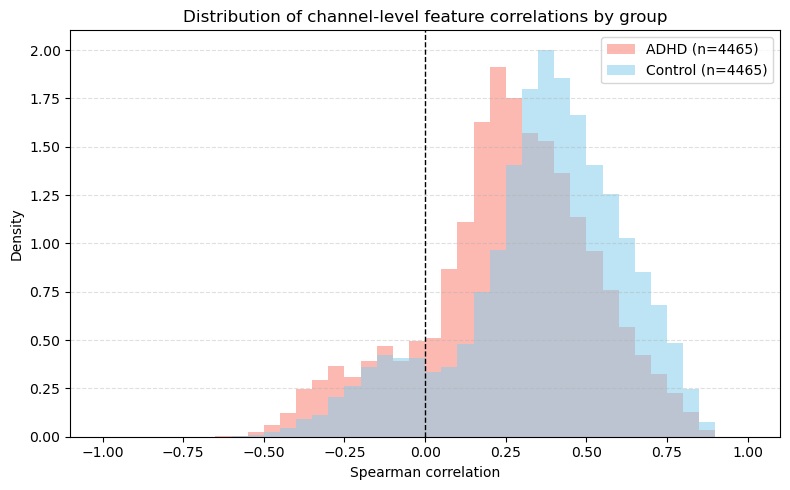

In [209]:
plot_correlation_distribution_by_group(
    group_corr_pairs_df,
    feature_subset="channel",
    title="Distribution of channel-level feature correlations by group",
    filename="1b_channel_correlation_distribution_by_group.png"
)

delta: 19 channel-level features
Table saved to: outputs\tabs\1b_spearman_channel_delta_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_channel_delta_Control.csv
theta: 19 channel-level features
Table saved to: outputs\tabs\1b_spearman_channel_theta_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_channel_theta_Control.csv
alpha: 19 channel-level features
Table saved to: outputs\tabs\1b_spearman_channel_alpha_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_channel_alpha_Control.csv
beta: 19 channel-level features
Table saved to: outputs\tabs\1b_spearman_channel_beta_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_channel_beta_Control.csv
theta_beta_ratio: 19 channel-level features
Table saved to: outputs\tabs\1b_spearman_channel_theta_beta_ratio_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_channel_theta_beta_ratio_Control.csv
Table saved to: outputs\tabs\1b_channel_correlations_separated_by_band.csv


,group,band,feature_1,feature_2,spearman_r,abs_spearman_r
0,ADHD,delta,Fp1_delta_power,Fp2_delta_power,0.807721,0.807721
1,ADHD,delta,Fp1_delta_power,F7_delta_power,0.478900,0.478900
2,ADHD,delta,Fp1_delta_power,F3_delta_power,0.636118,0.636118
3,ADHD,delta,Fp1_delta_power,Fz_delta_power,0.647435,0.647435
4,ADHD,delta,Fp1_delta_power,F4_delta_power,0.633157,0.633157



Number of correlations by group and band:


,band,group,n_correlations
0,alpha,ADHD,171
1,alpha,Control,171
2,beta,ADHD,171
3,beta,Control,171
4,delta,ADHD,171
5,delta,Control,171
6,theta,ADHD,171
7,theta,Control,171
8,theta_beta_ratio,ADHD,171
9,theta_beta_ratio,Control,171


Figure saved to: outputs\figures\1b_channel_correlation_distributions_by_band.png


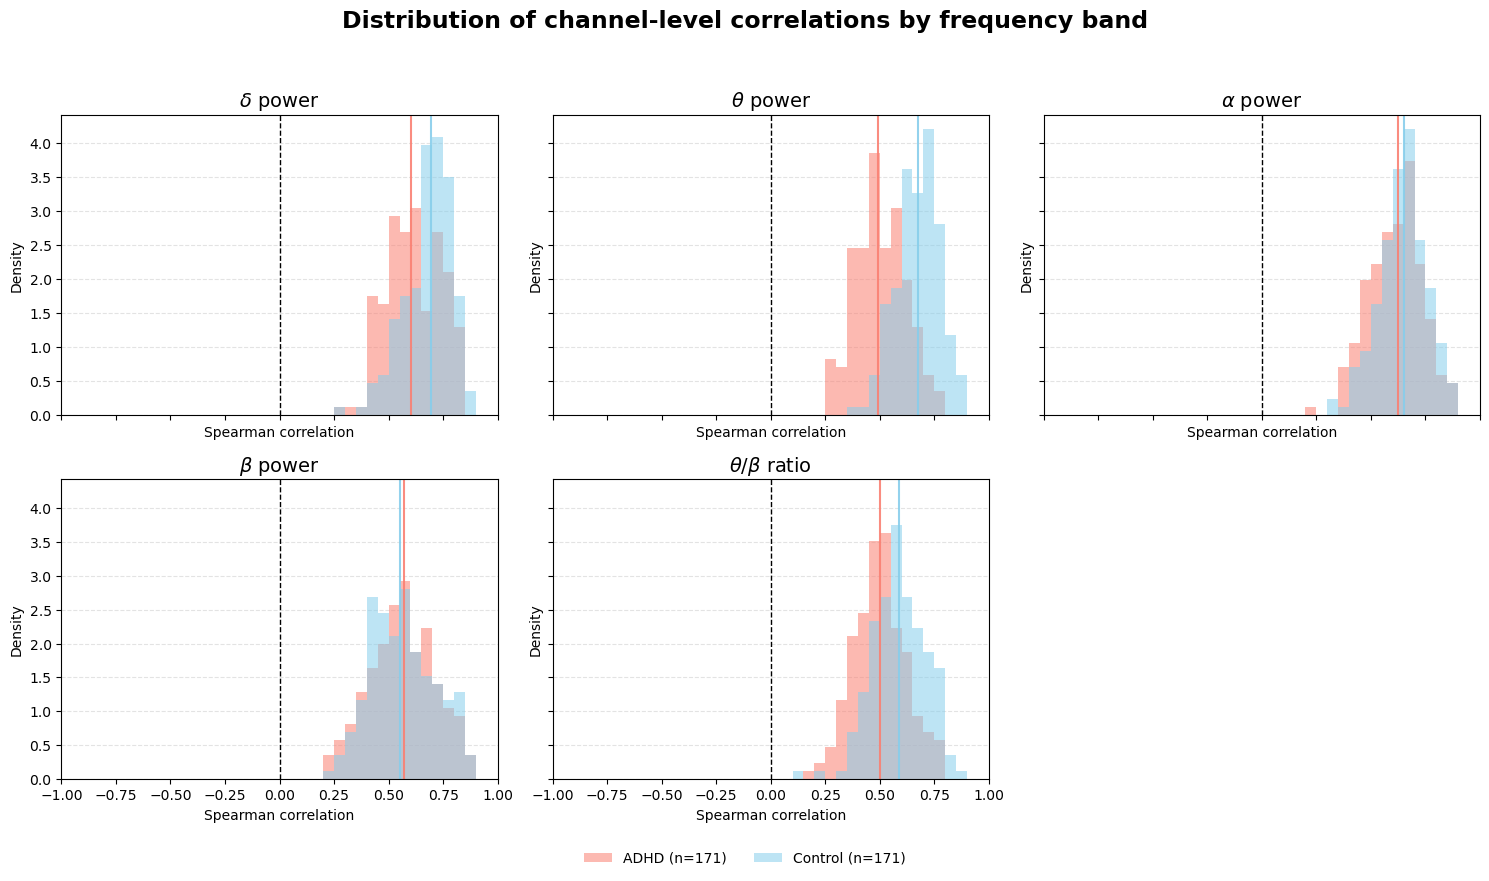

In [210]:
# ============================================================
# SPEARMAN CORRELATION DISTRIBUTIONS SEPARATED BY EEG BAND
# ============================================================

# For each band, correlations are computed only among the
# 19 channel-level features belonging to that same band.
#
# Example:
# Fp1_delta_power vs Fp2_delta_power
# Fp1_delta_power vs F3_delta_power
# ...
#
# Cross-band correlations such as delta vs alpha are excluded.


channel_band_specs = {
    "delta": {
        "suffix": "delta_power",
        "title": r"$\delta$ power"
    },
    "theta": {
        "suffix": "theta_power",
        "title": r"$\theta$ power"
    },
    "alpha": {
        "suffix": "alpha_power",
        "title": r"$\alpha$ power"
    },
    "beta": {
        "suffix": "beta_power",
        "title": r"$\beta$ power"
    },
    "theta_beta_ratio": {
        "suffix": "theta_beta_ratio",
        "title": r"$\theta/\beta$ ratio"
    }
}


def upper_triangle_correlation_pairs(
    corr_matrix,
    group_label,
    band_name
):
    """
    Convert the upper triangle of a correlation matrix into
    a table of unique channel-channel correlations.

    Self-correlations and duplicate pairs are excluded.
    """

    pairs = []
    feature_names = corr_matrix.columns.tolist()

    for i, feature_1 in enumerate(feature_names):

        for j in range(i + 1, len(feature_names)):

            feature_2 = feature_names[j]

            correlation = corr_matrix.loc[
                feature_1,
                feature_2
            ]

            pairs.append({
                "group": group_label,
                "band": band_name,
                "feature_1": feature_1,
                "feature_2": feature_2,
                "spearman_r": correlation,
                "abs_spearman_r": abs(correlation)
            })

    return pd.DataFrame(pairs)


# ------------------------------------------------------------
# Compute within-band correlation matrices and pairs
# ------------------------------------------------------------

band_corr_matrices = {}
band_corr_pair_tables = []


for band_name, band_info in channel_band_specs.items():

    suffix = band_info["suffix"]

    # Construct the expected feature names in channel order
    band_features = [
        f"{channel}_{suffix}"
        for channel in channel_order
        if f"{channel}_{suffix}" in features_df.columns
    ]

    print(
        f"{band_name}: "
        f"{len(band_features)} channel-level features"
    )

    if len(band_features) != len(channel_order):

        missing_features = [
            f"{channel}_{suffix}"
            for channel in channel_order
            if f"{channel}_{suffix}" not in features_df.columns
        ]

        print(
            "Warning — missing features:",
            missing_features
        )

    for group_label in ["ADHD", "Control"]:

        group_df = features_df.loc[
            features_df["Class"] == group_label
        ]

        # Spearman correlations among channels of one band only
        corr_matrix = group_df[
            band_features
        ].corr(
            method="spearman"
        )

        band_corr_matrices[
            (group_label, band_name)
        ] = corr_matrix

        # Save the band-specific matrix
        save_table(
            corr_matrix,
            (
                f"1b_spearman_channel_"
                f"{band_name}_{group_label}.csv"
            ),
            index=True
        )

        # Extract unique channel-channel pairs
        pair_table = upper_triangle_correlation_pairs(
            corr_matrix=corr_matrix,
            group_label=group_label,
            band_name=band_name
        )

        band_corr_pair_tables.append(
            pair_table
        )


# Single table containing all within-band pairs
channel_band_corr_pairs_df = pd.concat(
    band_corr_pair_tables,
    ignore_index=True
)

save_table(
    channel_band_corr_pairs_df,
    "1b_channel_correlations_separated_by_band.csv"
)

display(
    channel_band_corr_pairs_df.head()
)


# Check the expected number of correlations:
# 19 channels -> 19 * 18 / 2 = 171 unique pairs per group
print("\nNumber of correlations by group and band:")

display(
    channel_band_corr_pairs_df
    .groupby(["band", "group"])
    .size()
    .rename("n_correlations")
    .reset_index()
)


# ============================================================
# PLOT ALL BAND-SPECIFIC DISTRIBUTIONS IN ONE FIGURE
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

bins = np.linspace(
    -1,
    1,
    41
)

colors = {
    "ADHD": "salmon",
    "Control": "skyblue"
}


for ax, (band_name, band_info) in zip(
    axes,
    channel_band_specs.items()
):

    for group_label in ["ADHD", "Control"]:

        values = channel_band_corr_pairs_df.loc[
            (
                channel_band_corr_pairs_df["band"]
                == band_name
            )
            &
            (
                channel_band_corr_pairs_df["group"]
                == group_label
            ),
            "spearman_r"
        ].dropna()

        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.55,
            color=colors[group_label],
            label=(
                f"{group_label} "
                f"(n={len(values)})"
            )
        )

        # Group median, useful for visually comparing
        # the overall position of the two distributions
        median_value = values.median()

        ax.axvline(
            median_value,
            color=colors[group_label],
            linestyle="-",
            linewidth=1.5,
            alpha=0.9
        )

    # Zero-correlation reference
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_title(
        band_info["title"],
        fontsize=14
    )

    ax.set_xlim(
        -1,
        1
    )

    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    ax.set_axisbelow(True)


# The sixth panel is unused
for ax in axes[len(channel_band_specs):]:
    ax.axis("off")


# Axis labels only on the outer panels
for ax in axes[:len(channel_band_specs)]:
    ax.set_xlabel(
        "Spearman correlation"
    )
    ax.set_ylabel(
        "Density"
    )


# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.015)
)

fig.suptitle(
    "Distribution of channel-level correlations by frequency band",
    fontsize=17,
    fontweight="bold",
    y=0.98
)

fig.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)

save_figure(
    "1b_channel_correlation_distributions_by_band.png"
)

plt.show()

delta: 5 regional features
Table saved to: outputs\tabs\1b_spearman_regional_delta_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_regional_delta_Control.csv
theta: 5 regional features
Table saved to: outputs\tabs\1b_spearman_regional_theta_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_regional_theta_Control.csv
alpha: 5 regional features
Table saved to: outputs\tabs\1b_spearman_regional_alpha_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_regional_alpha_Control.csv
beta: 5 regional features
Table saved to: outputs\tabs\1b_spearman_regional_beta_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_regional_beta_Control.csv
theta_beta_ratio: 5 regional features
Table saved to: outputs\tabs\1b_spearman_regional_theta_beta_ratio_ADHD.csv
Table saved to: outputs\tabs\1b_spearman_regional_theta_beta_ratio_Control.csv
Table saved to: outputs\tabs\1b_regional_correlations_separated_by_band.csv


,group,band,feature_1,feature_2,spearman_r,abs_spearman_r
0,ADHD,delta,frontal_delta_power_mean,central_delta_power_mean,0.696774,0.696774
1,ADHD,delta,frontal_delta_power_mean,temporal_delta_power_mean,0.501692,0.501692
2,ADHD,delta,frontal_delta_power_mean,parietal_delta_power_mean,0.638657,0.638657
3,ADHD,delta,frontal_delta_power_mean,occipital_delta_power_mean,0.711105,0.711105
4,ADHD,delta,central_delta_power_mean,temporal_delta_power_mean,0.587626,0.587626



Number of regional correlations by group and band:


,band,group,n_correlations
0,alpha,ADHD,10
1,alpha,Control,10
2,beta,ADHD,10
3,beta,Control,10
4,delta,ADHD,10
5,delta,Control,10
6,theta,ADHD,10
7,theta,Control,10
8,theta_beta_ratio,ADHD,10
9,theta_beta_ratio,Control,10


Figure saved to: outputs\figures\1b_regional_correlation_distributions_by_band.png


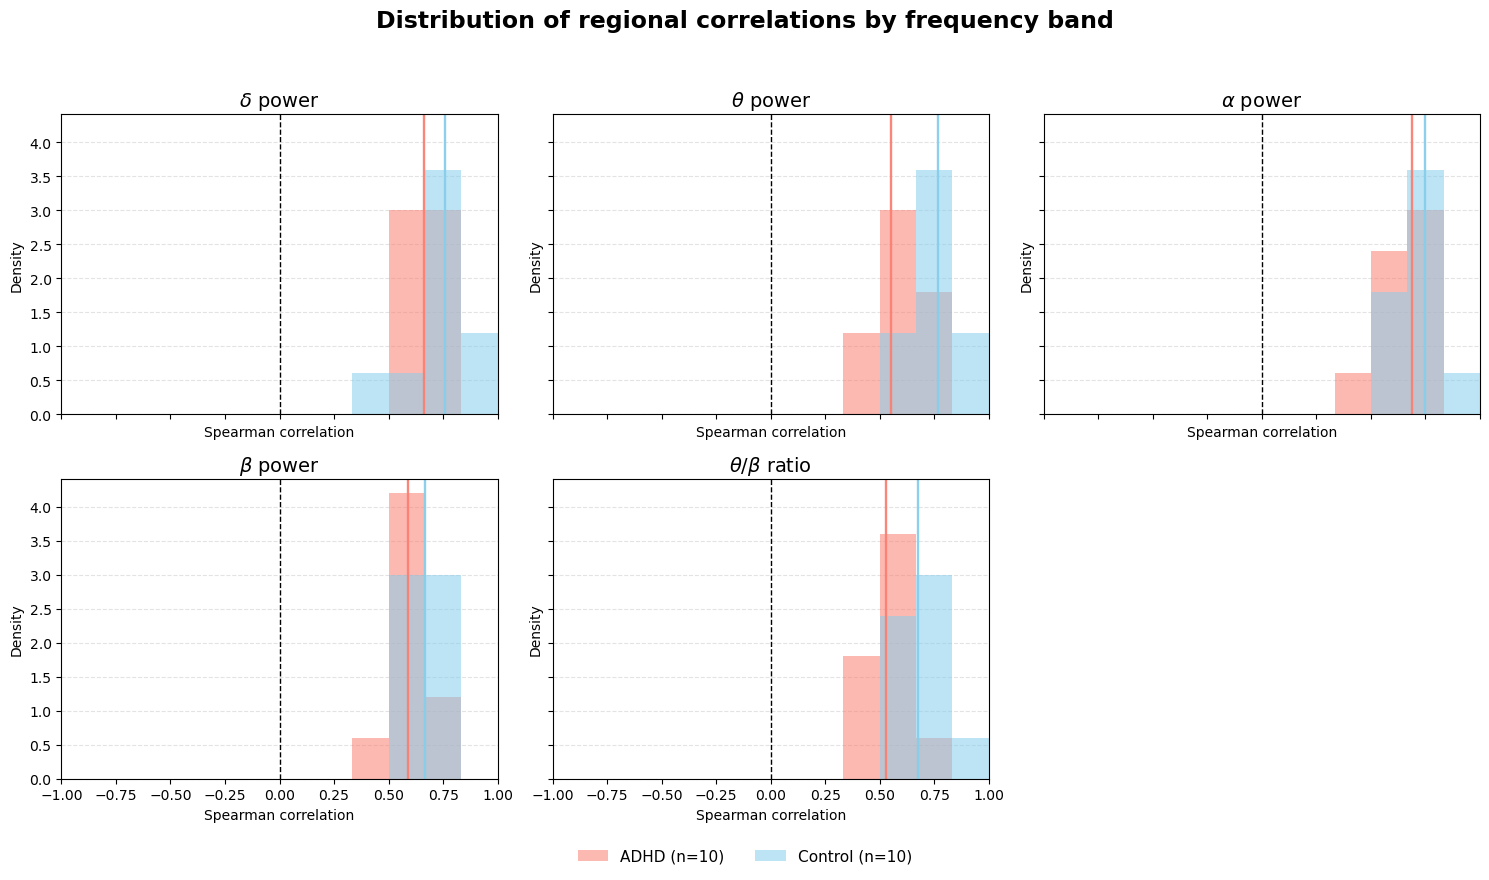

In [211]:
# ============================================================
# REGIONAL SPEARMAN CORRELATION DISTRIBUTIONS
# SEPARATED BY EEG FREQUENCY BAND
# ============================================================

# For each frequency band, correlations are computed only
# between the five regional features belonging to that band.
#
# Five regions generate:
# 5 * 4 / 2 = 10 unique region-region correlations
# for each group and each band.


regions = [
    "frontal",
    "central",
    "temporal",
    "parietal",
    "occipital"
]


regional_band_specs = {
    "delta": {
        "suffix": "delta_power_mean",
        "title": r"$\delta$ power"
    },
    "theta": {
        "suffix": "theta_power_mean",
        "title": r"$\theta$ power"
    },
    "alpha": {
        "suffix": "alpha_power_mean",
        "title": r"$\alpha$ power"
    },
    "beta": {
        "suffix": "beta_power_mean",
        "title": r"$\beta$ power"
    },
    "theta_beta_ratio": {
        "suffix": "theta_beta_ratio",
        "title": r"$\theta/\beta$ ratio"
    }
}


def extract_unique_correlation_pairs(
    corr_matrix,
    group_label,
    band_name
):
    """
    Extract unique feature-feature correlations from the
    upper triangle of a correlation matrix.

    Self-correlations and duplicate pairs are excluded.
    """

    pairs = []

    feature_names = corr_matrix.columns.tolist()

    for i, feature_1 in enumerate(feature_names):

        for j in range(i + 1, len(feature_names)):

            feature_2 = feature_names[j]

            corr_value = corr_matrix.loc[
                feature_1,
                feature_2
            ]

            pairs.append({
                "group": group_label,
                "band": band_name,
                "feature_1": feature_1,
                "feature_2": feature_2,
                "spearman_r": corr_value,
                "abs_spearman_r": abs(corr_value)
            })

    return pd.DataFrame(pairs)


# ------------------------------------------------------------
# Compute within-band regional correlations
# ------------------------------------------------------------

regional_band_corr_matrices = {}
regional_band_corr_pair_tables = []


for band_name, band_info in regional_band_specs.items():

    suffix = band_info["suffix"]

    # Expected regional feature names for this band
    band_features = [
        f"{region}_{suffix}"
        for region in regions
        if f"{region}_{suffix}" in features_df.columns
    ]

    print(
        f"{band_name}: "
        f"{len(band_features)} regional features"
    )

    # Check for missing regional features
    if len(band_features) != len(regions):

        missing_features = [
            f"{region}_{suffix}"
            for region in regions
            if f"{region}_{suffix}" not in features_df.columns
        ]

        print(
            "Warning — missing regional features:",
            missing_features
        )


    for group_label in ["ADHD", "Control"]:

        group_df = features_df.loc[
            features_df["Class"] == group_label
        ]

        # Correlation matrix among the five regions
        # for one frequency band only
        corr_matrix = group_df[
            band_features
        ].corr(
            method="spearman"
        )

        regional_band_corr_matrices[
            (group_label, band_name)
        ] = corr_matrix

        # Save each correlation matrix
        save_table(
            corr_matrix,
            (
                f"1b_spearman_regional_"
                f"{band_name}_{group_label}.csv"
            ),
            index=True
        )

        # Extract the 10 unique region-region correlations
        pair_table = extract_unique_correlation_pairs(
            corr_matrix=corr_matrix,
            group_label=group_label,
            band_name=band_name
        )

        regional_band_corr_pair_tables.append(
            pair_table
        )


# Combine all bands and groups
regional_band_corr_pairs_df = pd.concat(
    regional_band_corr_pair_tables,
    ignore_index=True
)


save_table(
    regional_band_corr_pairs_df,
    "1b_regional_correlations_separated_by_band.csv"
)


display(
    regional_band_corr_pairs_df.head()
)


# Verify that each group and band contains 10 correlations
print("\nNumber of regional correlations by group and band:")

display(
    regional_band_corr_pairs_df
    .groupby(["band", "group"])
    .size()
    .rename("n_correlations")
    .reset_index()
)


# ============================================================
# HISTOGRAMS IN THE SAME STYLE AS CHANNEL-LEVEL DISTRIBUTIONS
# ============================================================

fig, axes = plt.subplots(
    2,
    3,
    figsize=(15, 9),
    sharex=True,
    sharey=True,
    facecolor="white"
)

axes = axes.flatten()


# Fewer bins than the channel-level plot because there are
# only 10 correlations per group and band
bins = np.linspace(
    -1,
    1,
    13
)


colors = {
    "ADHD": "salmon",
    "Control": "skyblue"
}


for ax, (band_name, band_info) in zip(
    axes,
    regional_band_specs.items()
):

    for group_label in ["ADHD", "Control"]:

        values = regional_band_corr_pairs_df.loc[
            (
                regional_band_corr_pairs_df["band"]
                == band_name
            )
            &
            (
                regional_band_corr_pairs_df["group"]
                == group_label
            ),
            "spearman_r"
        ].dropna()


        ax.hist(
            values,
            bins=bins,
            density=True,
            alpha=0.55,
            color=colors[group_label],
            label=(
                f"{group_label} "
                f"(n={len(values)})"
            )
        )


        # Median correlation for the group
        median_value = values.median()

        ax.axvline(
            median_value,
            color=colors[group_label],
            linestyle="-",
            linewidth=1.7,
            alpha=0.95
        )


    # Reference line for zero correlation
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )


    ax.set_title(
        band_info["title"],
        fontsize=14
    )


    ax.set_xlim(
        -1,
        1
    )


    ax.grid(
        axis="y",
        linestyle="--",
        alpha=0.35
    )

    ax.set_axisbelow(True)


# Remove unused sixth panel
for ax in axes[len(regional_band_specs):]:
    ax.axis("off")


# Axis labels
for ax in axes[:len(regional_band_specs)]:

    ax.set_xlabel(
        "Spearman correlation"
    )

    ax.set_ylabel(
        "Density"
    )


# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.015),
    fontsize=11
)


fig.suptitle(
    "Distribution of regional correlations by frequency band",
    fontsize=17,
    fontweight="bold",
    y=0.98
)


fig.tight_layout(
    rect=[0, 0.06, 1, 0.95]
)


save_figure(
    "1b_regional_correlation_distributions_by_band.png"
)

plt.show()

In [212]:
# Spearman correlation matrix across all EEG features

all_feature_corr = features_df[eeg_feature_cols].corr(
    method="spearman"
)

print("Correlation matrix shape:", all_feature_corr.shape)

display(all_feature_corr)

Correlation matrix shape: (120, 120)


,Fp1_delta_power,Fp1_theta_power,Fp1_alpha_power,Fp1_beta_power,Fp1_theta_beta_ratio,Fp2_delta_power,Fp2_theta_power,Fp2_alpha_power,Fp2_beta_power,Fp2_theta_beta_ratio,...,temporal_delta_power_mean,temporal_theta_power_mean,temporal_alpha_power_mean,temporal_beta_power_mean,temporal_theta_beta_ratio,occipital_delta_power_mean,occipital_theta_power_mean,occipital_alpha_power_mean,occipital_beta_power_mean,occipital_theta_beta_ratio
Fp1_delta_power,1.000000,0.805047,0.567796,0.440123,0.456700,0.806937,0.688674,0.464117,0.384257,0.405575,...,0.490719,0.515465,0.309396,0.202547,0.323581,0.778086,0.622673,0.396051,0.289209,0.289744
Fp1_theta_power,0.805047,1.000000,0.764592,0.610351,0.441356,0.595339,0.765980,0.583281,0.475505,0.381669,...,0.279325,0.501145,0.354803,0.226270,0.302466,0.549980,0.631236,0.447223,0.359524,0.243361
Fp1_alpha_power,0.567796,0.764592,1.000000,0.703902,0.094398,0.325728,0.514456,0.674197,0.433363,0.138450,...,0.085388,0.292813,0.589243,0.321847,0.017640,0.364476,0.449695,0.544879,0.367179,0.052093
Fp1_beta_power,0.440123,0.610351,0.703902,1.000000,-0.375193,0.219747,0.361408,0.390381,0.582435,-0.248855,...,0.063799,0.229393,0.274285,0.404349,-0.107892,0.211252,0.287190,0.315161,0.406368,-0.121657
Fp1_theta_beta_ratio,0.456700,0.441356,0.094398,-0.375193,1.000000,0.500081,0.507668,0.251592,-0.098374,0.805988,...,0.303136,0.374848,0.126351,-0.218006,0.555846,0.424299,0.407099,0.170681,-0.063067,0.455595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
occipital_delta_power_mean,0.778086,0.549980,0.364476,0.211252,0.424299,0.751260,0.579935,0.408183,0.281893,0.385192,...,0.594391,0.579908,0.380138,0.223262,0.377334,1.000000,0.808732,0.544567,0.297406,0.466854
occipital_theta_power_mean,0.622673,0.631236,0.449695,0.287190,0.407099,0.531242,0.580280,0.450325,0.283139,0.375545,...,0.436763,0.621860,0.447853,0.176927,0.442020,0.808732,1.000000,0.754844,0.427930,0.484535
occipital_alpha_power_mean,0.396051,0.447223,0.544879,0.315161,0.170681,0.299065,0.368466,0.507160,0.286641,0.155717,...,0.174041,0.371664,0.587522,0.261272,0.121345,0.544567,0.754844,1.000000,0.604051,0.097182
occipital_beta_power_mean,0.289209,0.359524,0.367179,0.406368,-0.063067,0.224326,0.257573,0.296925,0.394262,-0.123649,...,0.196748,0.325085,0.328235,0.458088,-0.118277,0.297406,0.427930,0.604051,1.000000,-0.514490


Figure saved to: outputs\figures\1b_spearman_correlation_all_features.png


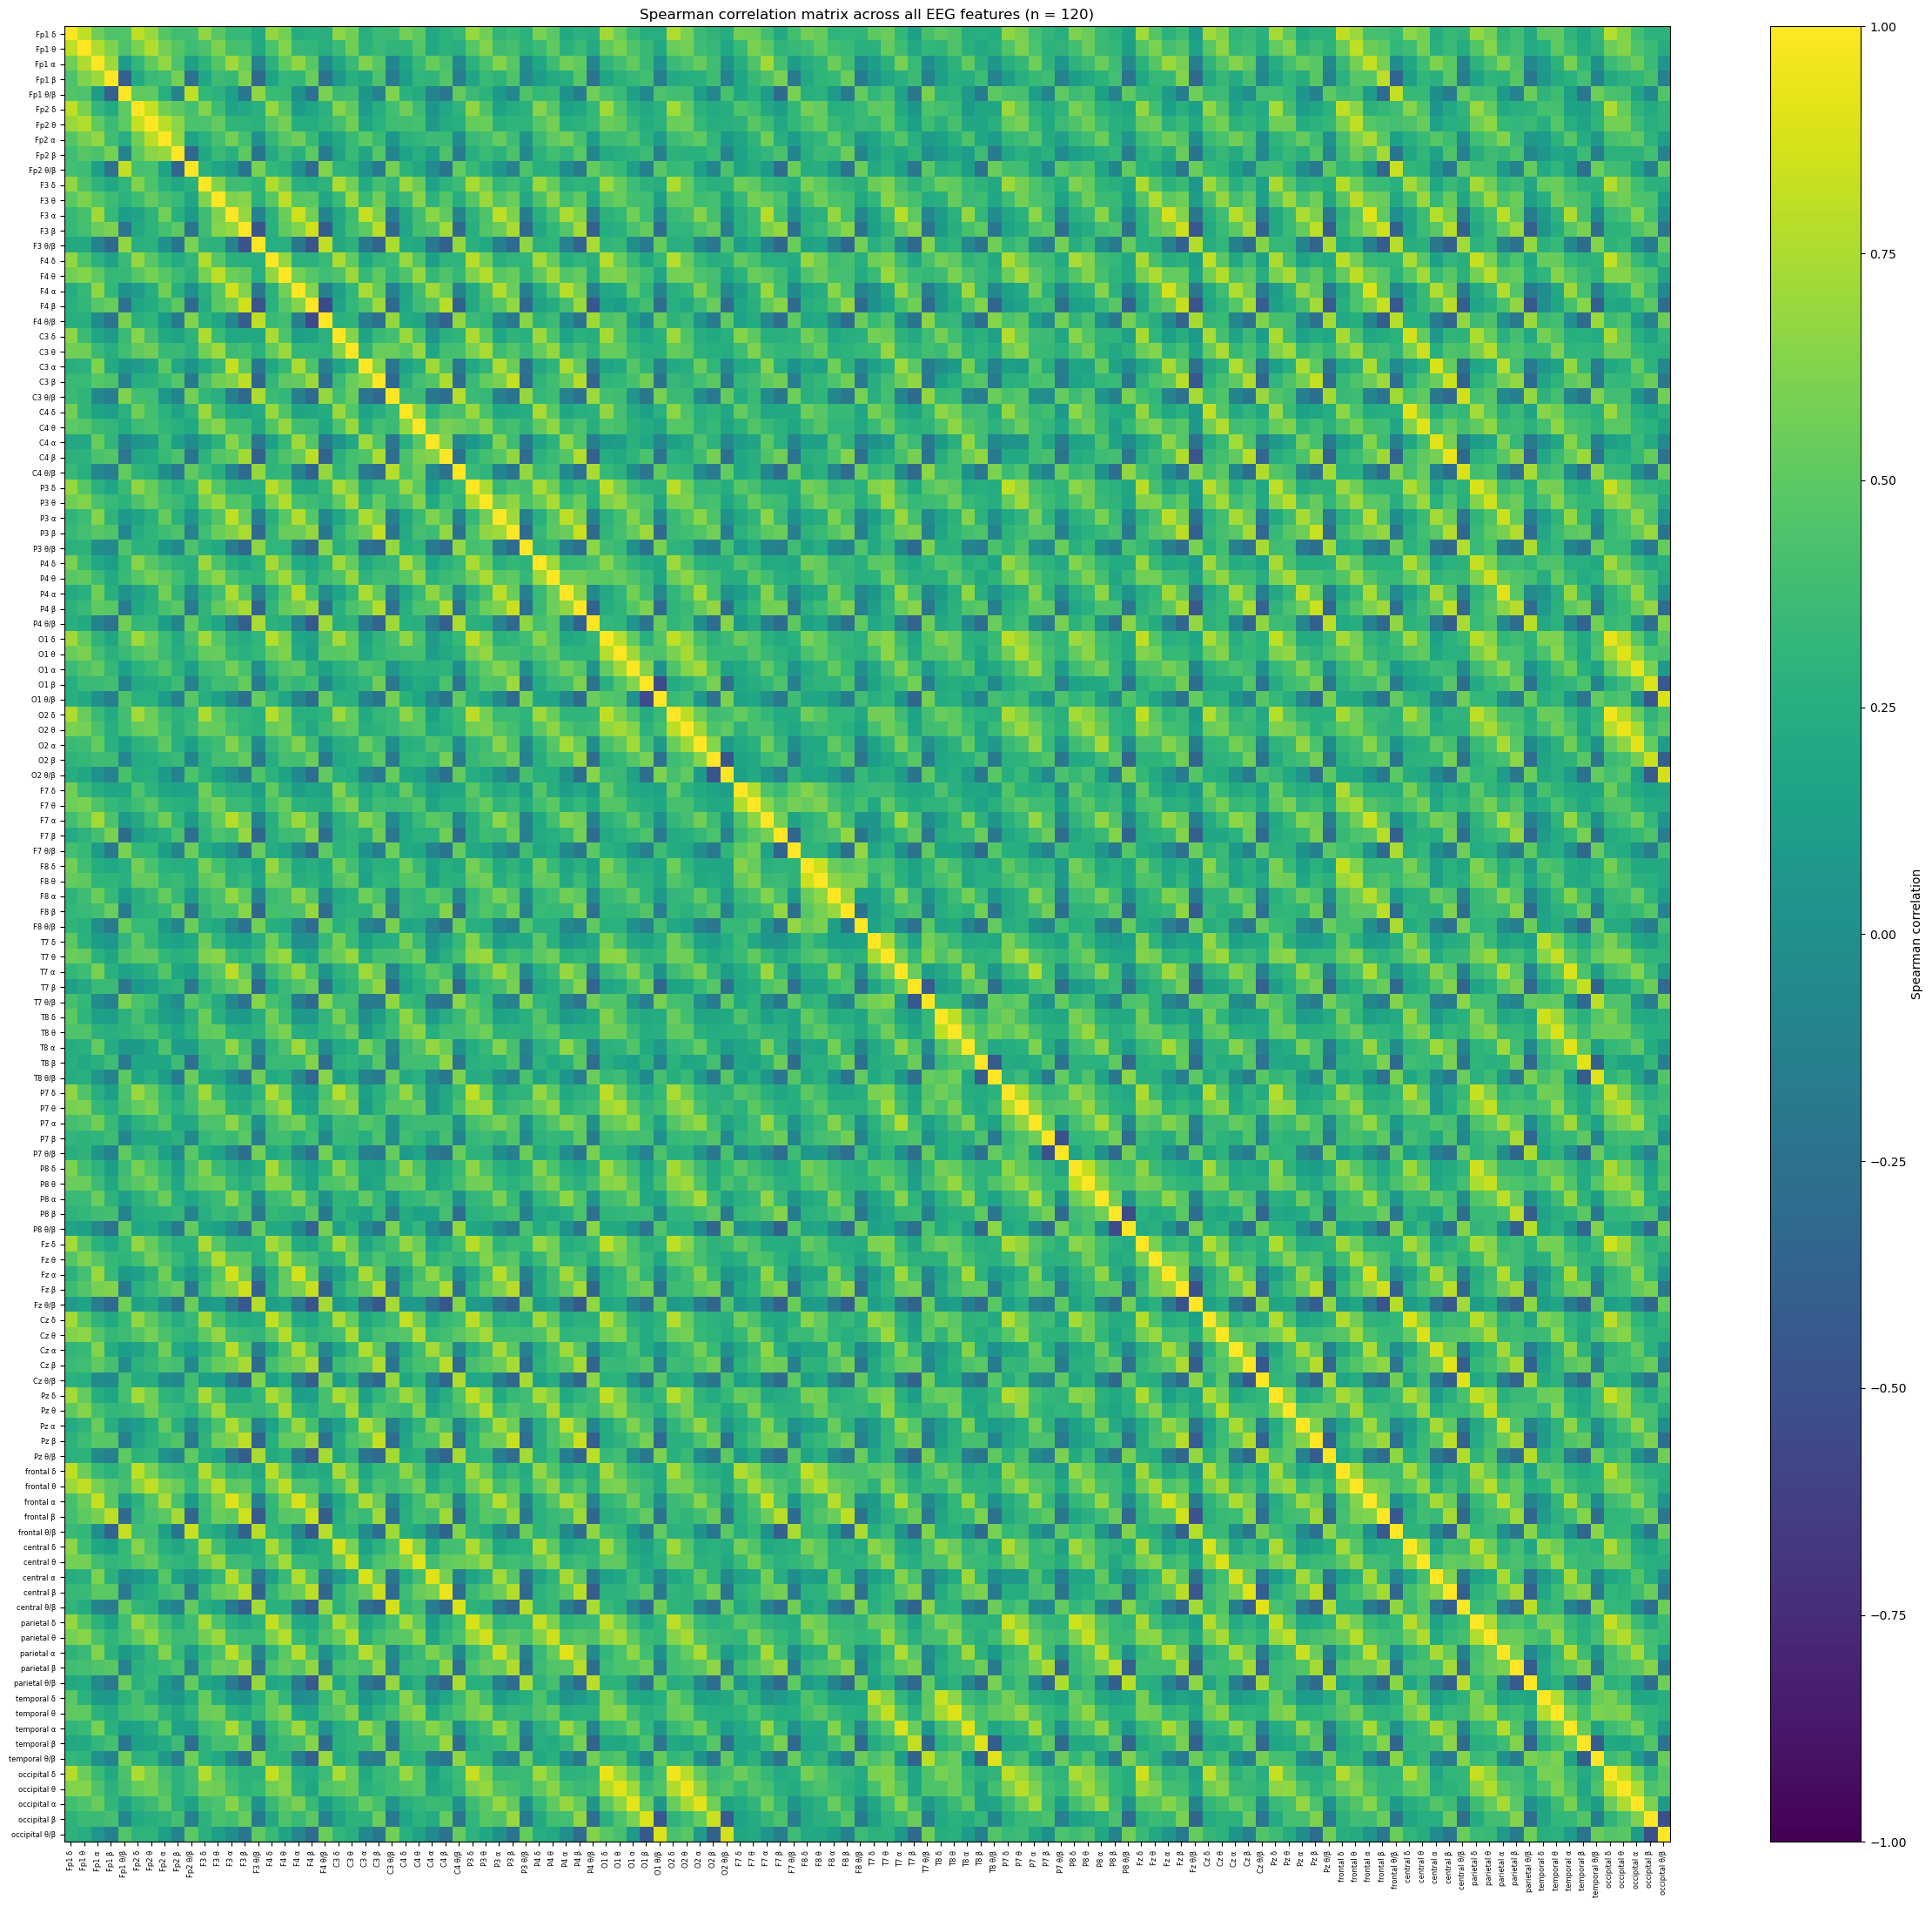

In [213]:
plt.figure(figsize=(24, 22))

plt.imshow(
    all_feature_corr.values,
    aspect="auto",
    vmin=-1,
    vmax=1
)

plt.colorbar(label="Spearman correlation")

feature_labels = [
    short_feature_name(feature)
    for feature in all_feature_corr.columns
]

plt.xticks(
    ticks=np.arange(len(feature_labels)),
    labels=feature_labels,
    rotation=90,
    fontsize=6
)

plt.yticks(
    ticks=np.arange(len(feature_labels)),
    labels=feature_labels,
    fontsize=6
)

plt.title(
    f"Spearman correlation matrix across all EEG features (n = {len(eeg_feature_cols)})"
)

plt.tight_layout()
save_figure("1b_spearman_correlation_all_features.png")
plt.show()

In [214]:
# Extract strongest feature-feature correlations

corr_pairs = []

for i, feature_1 in enumerate(all_feature_corr.columns):
    for j, feature_2 in enumerate(all_feature_corr.columns):

        # Avoid duplicate pairs and self-correlations
        if j <= i:
            continue

        corr_value = all_feature_corr.loc[
            feature_1,
            feature_2
        ]

        corr_pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "spearman_r": corr_value,
            "abs_spearman_r": abs(corr_value)
        })

corr_pairs_df = pd.DataFrame(corr_pairs)

corr_pairs_df = corr_pairs_df.sort_values(
    "abs_spearman_r",
    ascending=False
)

display(corr_pairs_df.head(30))

,feature_1,feature_2,spearman_r,abs_spearman_r
4434,O2_delta_power,occipital_delta_power_mean,0.953929,0.953929
3028,C4_beta_power,central_beta_power_mean,0.943903,0.943903
4508,O2_theta_power,occipital_theta_power_mean,0.939676,0.939676
4054,O1_delta_power,occipital_delta_power_mean,0.934846,0.934846
4211,O1_alpha_power,occipital_alpha_power_mean,0.926223,0.926223
2749,C4_delta_power,central_delta_power_mean,0.918155,0.918155
4581,O2_alpha_power,occipital_alpha_power_mean,0.914822,0.914822
5858,T8_beta_power,temporal_beta_power_mean,0.909917,0.909917
5806,T8_alpha_power,temporal_alpha_power_mean,0.909443,0.909443
3806,P4_alpha_power,parietal_alpha_power_mean,0.909403,0.909403


In [215]:
# Strongest positive correlations

strongest_positive_corr = corr_pairs_df.sort_values(
    "spearman_r",
    ascending=False
).head(20)

display(strongest_positive_corr)

,feature_1,feature_2,spearman_r,abs_spearman_r
4434,O2_delta_power,occipital_delta_power_mean,0.953929,0.953929
3028,C4_beta_power,central_beta_power_mean,0.943903,0.943903
4508,O2_theta_power,occipital_theta_power_mean,0.939676,0.939676
4054,O1_delta_power,occipital_delta_power_mean,0.934846,0.934846
4211,O1_alpha_power,occipital_alpha_power_mean,0.926223,0.926223
2749,C4_delta_power,central_delta_power_mean,0.918155,0.918155
4581,O2_alpha_power,occipital_alpha_power_mean,0.914822,0.914822
5858,T8_beta_power,temporal_beta_power_mean,0.909917,0.909917
5806,T8_alpha_power,temporal_alpha_power_mean,0.909443,0.909443
3806,P4_alpha_power,parietal_alpha_power_mean,0.909403,0.909403


In [216]:
# Strongest negative correlations

strongest_negative_corr = corr_pairs_df.sort_values(
    "spearman_r",
    ascending=True
).head(20)

display(strongest_negative_corr)

,feature_1,feature_2,spearman_r,abs_spearman_r
1989,F4_beta_power,F4_theta_beta_ratio,-0.552202,0.552202
4214,O1_beta_power,O1_theta_beta_ratio,-0.533498,0.533498
6279,P8_beta_power,P8_theta_beta_ratio,-0.531710,0.531710
7139,occipital_beta_power_mean,occipital_theta_beta_ratio,-0.514490,0.514490
6474,Fz_beta_power,Fz_theta_beta_ratio,-0.499472,0.499472
6059,P7_beta_power,P7_theta_beta_ratio,-0.496735,0.496735
2054,F4_beta_power,Fz_theta_beta_ratio,-0.492061,0.492061
1578,F3_theta_beta_ratio,F4_beta_power,-0.491119,0.491119
6523,Fz_theta_beta_ratio,frontal_beta_power_mean,-0.490137,0.490137
1469,F3_beta_power,F3_theta_beta_ratio,-0.475701,0.475701


delta: 61 unique pairs displayed
theta: 40 unique pairs displayed
alpha: 40 unique pairs displayed
beta: 30 unique pairs displayed
theta_beta_ratio: 21 unique pairs displayed
Figure saved to: outputs\figures\1b_channel_spearman_correlation_networks_horizontal.png


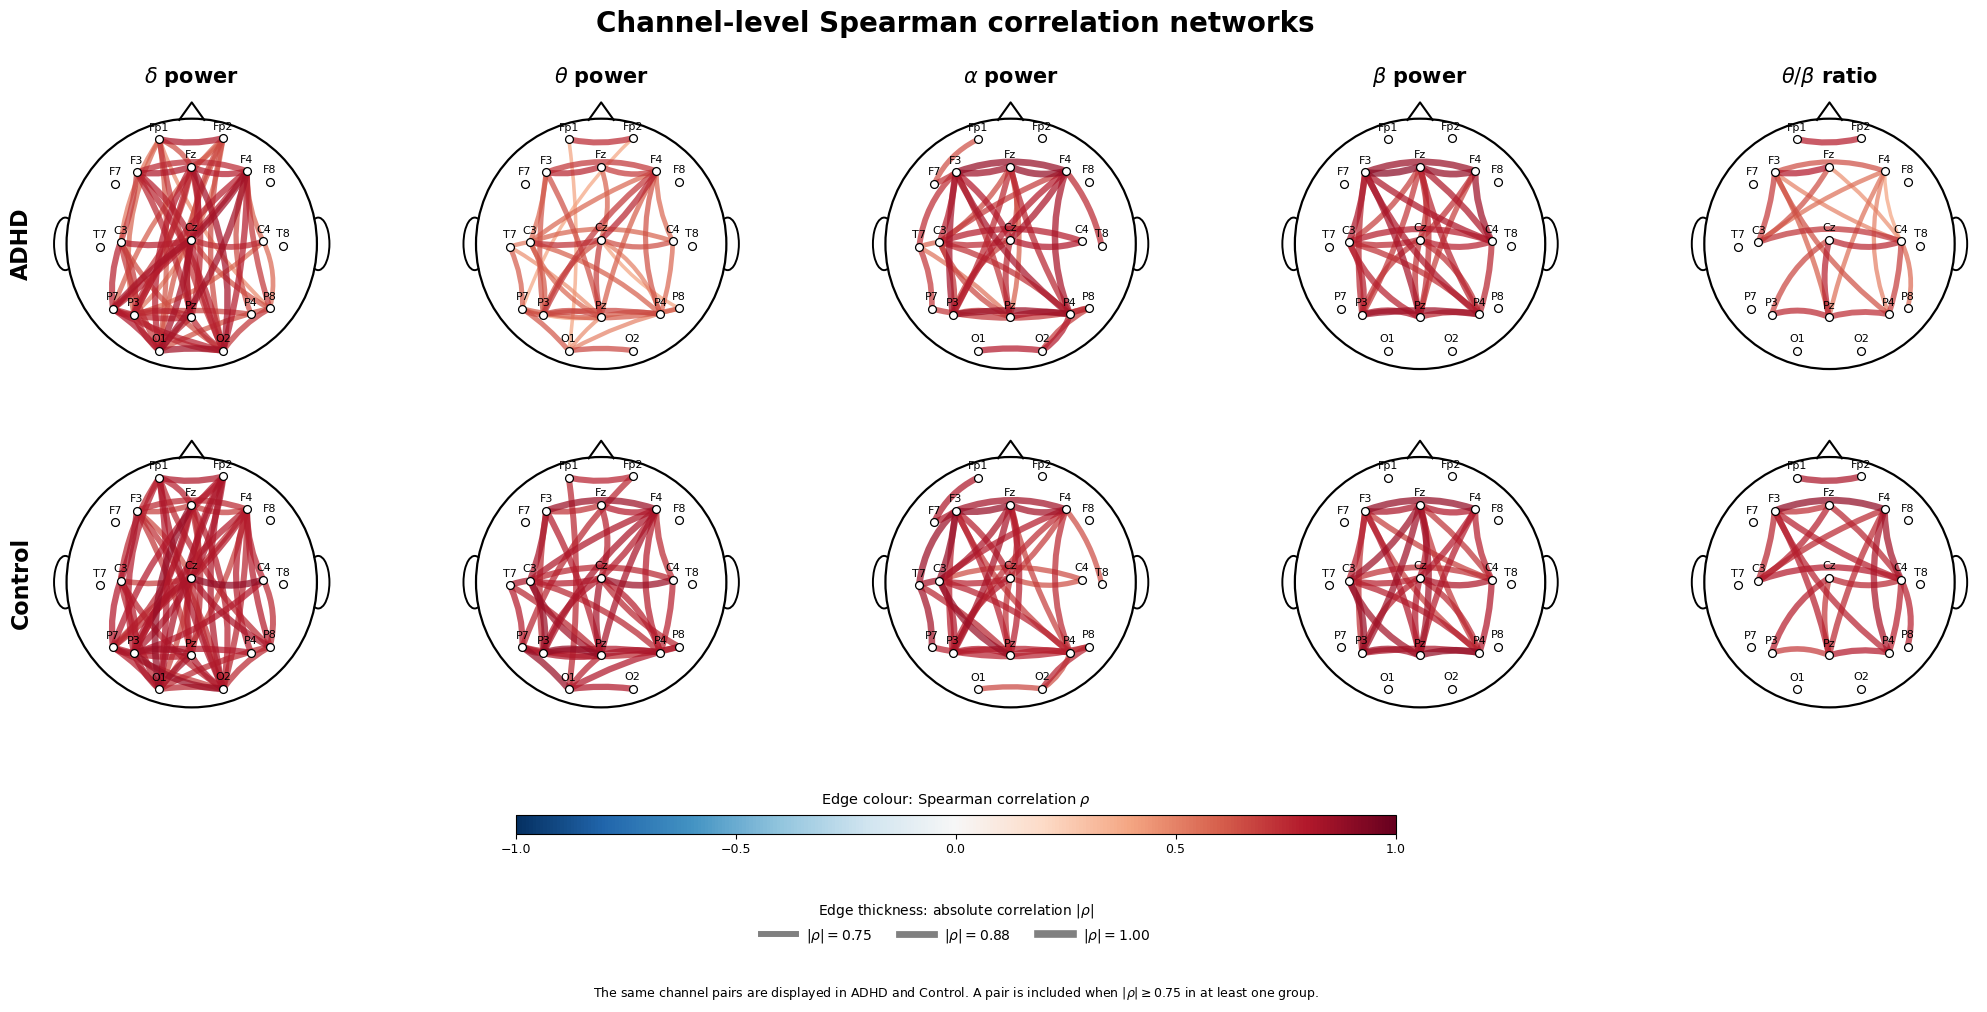

In [217]:
# ============================================================
# CHANNEL-LEVEL SPEARMAN CORRELATION NETWORKS
# HORIZONTAL LAYOUT: 2 GROUPS × 5 FREQUENCY BANDS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import mne

from matplotlib.lines import Line2D
from matplotlib.patches import Circle, Arc, FancyArrowPatch


# ------------------------------------------------------------
# 1. General settings
# ------------------------------------------------------------

CHANNEL_ORDER = [
    "Fp1", "Fp2",
    "F7", "F3", "Fz", "F4", "F8",
    "T7", "C3", "Cz", "C4", "T8",
    "P7", "P3", "Pz", "P4", "P8",
    "O1", "O2"
]

GROUP_ORDER = [
    "ADHD",
    "Control"
]

BAND_TITLES = {
    "delta": r"$\delta$ power",
    "theta": r"$\theta$ power",
    "alpha": r"$\alpha$ power",
    "beta": r"$\beta$ power",
    "theta_beta_ratio": r"$\theta/\beta$ ratio"
}


# Possible options:
#
# "threshold": show every pair with |rho| >= MIN_ABS_RHO
#              in at least one group
#
# "top_n":     show the union of the strongest
#              TOP_N_PER_GROUP pairs in the two groups
#
# "all":       show all 171 possible channel pairs

SELECTION_MODE = "threshold"

MIN_ABS_RHO = 0.75
TOP_N_PER_GROUP = 10


# Electrode appearance
CHANNEL_MARKER_SIZE = 32
CHANNEL_LABEL_FONTSIZE = 8


# Edge thickness
MIN_LINEWIDTH = 0.6
MAX_LINEWIDTH = 5.5


# Edge colour
CORRELATION_CMAP = plt.get_cmap(
    "RdBu_r"
)

CORRELATION_NORM = mpl.colors.Normalize(
    vmin=-1.0,
    vmax=1.0
)


# ------------------------------------------------------------
# 2. Check the input DataFrame
# ------------------------------------------------------------

required_columns = {
    "group",
    "band",
    "feature_1",
    "feature_2",
    "spearman_r",
    "abs_spearman_r"
}

missing_columns = (
    required_columns
    - set(channel_band_corr_pairs_df.columns)
)

if missing_columns:

    raise ValueError(
        "Missing columns in channel_band_corr_pairs_df: "
        + ", ".join(
            sorted(missing_columns)
        )
    )


# ------------------------------------------------------------
# 3. Extract channel names from feature names
# ------------------------------------------------------------

def channel_from_feature(feature_name):
    """
    Extract the channel name from a channel-level feature.

    Examples
    --------
    F3_alpha_power -> F3
    Pz_theta_beta_ratio -> Pz
    """

    channel_name = str(
        feature_name
    ).split(
        "_",
        1
    )[0]

    if channel_name not in CHANNEL_ORDER:

        raise ValueError(
            "Could not identify a valid EEG channel "
            f"from feature: {feature_name}"
        )

    return channel_name


plot_pairs_df = (
    channel_band_corr_pairs_df
    .copy()
)

plot_pairs_df["channel_1"] = (
    plot_pairs_df["feature_1"]
    .apply(channel_from_feature)
)

plot_pairs_df["channel_2"] = (
    plot_pairs_df["feature_2"]
    .apply(channel_from_feature)
)


# Canonical representation of a channel pair:
# F3-Fz and Fz-F3 are considered the same pair
plot_pairs_df["channel_pair"] = (
    plot_pairs_df.apply(
        lambda row: tuple(
            sorted([
                row["channel_1"],
                row["channel_2"]
            ])
        ),
        axis=1
    )
)


# ------------------------------------------------------------
# 4. Electrode positions from the MNE montage
# ------------------------------------------------------------

correlation_montage = (
    mne.channels.make_standard_montage(
        "standard_1020"
    )
)

montage_positions = (
    correlation_montage
    .get_positions()["ch_pos"]
)


missing_positions = [
    channel
    for channel in CHANNEL_ORDER
    if channel not in montage_positions
]

if missing_positions:

    raise ValueError(
        "Missing standard montage positions for: "
        + ", ".join(missing_positions)
    )


channel_xy = np.array([
    montage_positions[channel][:2]
    for channel in CHANNEL_ORDER
])


# Centre coordinates
channel_xy = (
    channel_xy
    - channel_xy.mean(axis=0)
)


# Scale coordinates inside a schematic head of radius 1
maximum_radius = np.max(
    np.linalg.norm(
        channel_xy,
        axis=1
    )
)

channel_xy = (
    channel_xy
    / (maximum_radius * 1.12)
)


channel_positions = {
    channel: channel_xy[index]
    for index, channel
    in enumerate(CHANNEL_ORDER)
}


# ------------------------------------------------------------
# 5. Draw the schematic head
# ------------------------------------------------------------

def draw_eeg_head(ax):
    """
    Draw only the head outline.

    Electrodes and labels are drawn later, after the edges,
    so that they remain visible above the connections.
    """

    head = Circle(
        (0, 0),
        radius=1.0,
        fill=False,
        edgecolor="black",
        linewidth=1.6,
        zorder=1
    )

    ax.add_patch(head)


    # Nose
    ax.plot(
        [-0.10, 0.00, 0.10],
        [0.99, 1.13, 0.99],
        color="black",
        linewidth=1.5,
        clip_on=False,
        zorder=1
    )


    # Left ear
    left_ear = Arc(
        (-1.01, 0),
        width=0.18,
        height=0.42,
        angle=0,
        theta1=80,
        theta2=280,
        color="black",
        linewidth=1.4
    )


    # Right ear
    right_ear = Arc(
        (1.01, 0),
        width=0.18,
        height=0.42,
        angle=0,
        theta1=-100,
        theta2=100,
        color="black",
        linewidth=1.4
    )

    ax.add_patch(left_ear)
    ax.add_patch(right_ear)


    ax.set_xlim(
        -1.18,
        1.18
    )

    ax.set_ylim(
        -1.13,
        1.20
    )

    ax.set_aspect(
        "equal"
    )

    ax.axis(
        "off"
    )


def draw_electrodes_and_labels(ax):
    """
    Draw electrodes and channel labels above the edges.
    """

    for channel in CHANNEL_ORDER:

        x, y = channel_positions[channel]

        ax.scatter(
            x,
            y,
            s=CHANNEL_MARKER_SIZE,
            facecolor="white",
            edgecolor="black",
            linewidth=0.9,
            zorder=10
        )

        ax.text(
            x,
            y + 0.055,
            channel,
            ha="center",
            va="bottom",
            fontsize=CHANNEL_LABEL_FONTSIZE,
            color="black",
            zorder=11
        )


# ------------------------------------------------------------
# 6. Edge appearance
# ------------------------------------------------------------

def deterministic_curvature(
    channel_1,
    channel_2
):
    """
    Assign a reproducible curvature to each channel pair.
    """

    ordered_pair = sorted([
        channel_1,
        channel_2
    ])

    pair_string = (
        f"{ordered_pair[0]}-"
        f"{ordered_pair[1]}"
    )

    pair_code = sum(
        ord(character)
        for character in pair_string
    )

    curvature_values = [
        -0.18,
        -0.12,
        -0.07,
        0.07,
        0.12,
        0.18
    ]

    return curvature_values[
        pair_code
        % len(curvature_values)
    ]


def correlation_linewidth(rho):
    """
    Convert |Spearman rho| into line thickness.
    """

    absolute_rho = np.clip(
        abs(float(rho)),
        0.0,
        1.0
    )

    return (
        MIN_LINEWIDTH
        +
        absolute_rho
        * (
            MAX_LINEWIDTH
            - MIN_LINEWIDTH
        )
    )


def draw_correlation_edge(
    ax,
    channel_1,
    channel_2,
    rho
):
    """
    Draw one curved channel-channel correlation.

    Colour represents signed rho.
    Thickness represents absolute rho.
    """

    start_position = (
        channel_positions[channel_1]
    )

    end_position = (
        channel_positions[channel_2]
    )

    curvature = deterministic_curvature(
        channel_1,
        channel_2
    )

    edge = FancyArrowPatch(
        posA=start_position,
        posB=end_position,

        arrowstyle="-",

        connectionstyle=(
            f"arc3,rad={curvature}"
        ),

        linewidth=correlation_linewidth(
            rho
        ),

        color=CORRELATION_CMAP(
            CORRELATION_NORM(rho)
        ),

        alpha=0.72,
        zorder=3
    )

    ax.add_patch(edge)


# ------------------------------------------------------------
# 7. Select comparable channel pairs
# ------------------------------------------------------------

def select_common_pairs_for_band(
    pairs_df,
    band_name,
    selection_mode="threshold",
    min_abs_rho=0.75,
    top_n_per_group=10
):
    """
    Select the union of the pairs retained in ADHD and Control.

    The same channel pairs are displayed in both panels,
    allowing a direct comparison between the two groups.
    """

    band_df = pairs_df.loc[
        pairs_df["band"] == band_name
    ].copy()

    selected_pairs = set()


    for group_label in GROUP_ORDER:

        group_df = band_df.loc[
            band_df["group"] == group_label
        ].copy()


        if selection_mode == "threshold":

            selected_group_df = group_df.loc[
                group_df["abs_spearman_r"]
                >= min_abs_rho
            ]


        elif selection_mode == "top_n":

            selected_group_df = (
                group_df
                .sort_values(
                    "abs_spearman_r",
                    ascending=False
                )
                .head(top_n_per_group)
            )


        elif selection_mode == "all":

            selected_group_df = group_df


        else:

            raise ValueError(
                "SELECTION_MODE must be "
                "'threshold', 'top_n', or 'all'."
            )


        selected_pairs.update(
            selected_group_df[
                "channel_pair"
            ].tolist()
        )


    selected_df = band_df.loc[
        band_df["channel_pair"].isin(
            selected_pairs
        )
    ].copy()

    return selected_df


# ------------------------------------------------------------
# 8. Select pairs for every frequency band
# ------------------------------------------------------------

selected_pairs_by_band = {}


for band_name in BAND_TITLES:

    selected_pairs_by_band[band_name] = (
        select_common_pairs_for_band(
            pairs_df=plot_pairs_df,
            band_name=band_name,
            selection_mode=SELECTION_MODE,
            min_abs_rho=MIN_ABS_RHO,
            top_n_per_group=TOP_N_PER_GROUP
        )
    )


    n_unique_pairs = (
        selected_pairs_by_band[
            band_name
        ]["channel_pair"]
        .nunique()
    )


    print(
        f"{band_name}: "
        f"{n_unique_pairs} unique pairs displayed"
    )


# ------------------------------------------------------------
# 9. Description of the selection rule
# ------------------------------------------------------------

if SELECTION_MODE == "threshold":

    selection_description = (
        "The same channel pairs are displayed in ADHD and Control. "
        "A pair is included when "
        rf"$|\rho| \geq {MIN_ABS_RHO:.2f}$ "
        "in at least one group."
    )


elif SELECTION_MODE == "top_n":

    selection_description = (
        "The same channel pairs are displayed in ADHD and Control. "
        f"Pairs are the union of the {TOP_N_PER_GROUP} strongest "
        "absolute correlations in each group."
    )


else:

    selection_description = (
        "All 171 possible channel pairs are displayed "
        "in both ADHD and Control."
    )


# ------------------------------------------------------------
# 10. Create the horizontal 2 × 5 figure
# ------------------------------------------------------------

n_bands = len(BAND_TITLES)


fig, axes = plt.subplots(
    nrows=2,
    ncols=n_bands,
    figsize=(22, 10.5),
    facecolor="white"
)


for column_index, (
    band_name,
    band_title
) in enumerate(
    BAND_TITLES.items()
):

    selected_band_df = (
        selected_pairs_by_band[
            band_name
        ]
    )


    for row_index, group_label in enumerate(
        GROUP_ORDER
    ):

        ax = axes[
            row_index,
            column_index
        ]


        # Draw head outline first
        draw_eeg_head(
            ax
        )


        group_edges = selected_band_df.loc[
            selected_band_df["group"]
            == group_label
        ].copy()


        # Draw weaker edges first,
        # so stronger edges remain more visible
        group_edges = (
            group_edges
            .sort_values(
                "abs_spearman_r",
                ascending=True
            )
        )


        for _, edge_row in group_edges.iterrows():

            draw_correlation_edge(
                ax=ax,

                channel_1=edge_row[
                    "channel_1"
                ],

                channel_2=edge_row[
                    "channel_2"
                ],

                rho=float(
                    edge_row[
                        "spearman_r"
                    ]
                )
            )


        # Draw electrodes and labels above the connections
        draw_electrodes_and_labels(
            ax
        )


        # Frequency-band titles above the first row
        if row_index == 0:

            ax.set_title(
                band_title,
                fontsize=15,
                fontweight="bold",
                pad=8
            )


        # Group names on the left side
        if column_index == 0:

            ax.text(
                -1.36,
                0,

                group_label,

                rotation=90,

                ha="center",
                va="center",

                fontsize=16,
                fontweight="bold"
            )


# ------------------------------------------------------------
# 11. Main title
# ------------------------------------------------------------

fig.suptitle(
    "Channel-level Spearman correlation networks",
    fontsize=20,
    fontweight="bold",
    y=0.965
)


# ------------------------------------------------------------
# 12. Layout of the ten head maps
# ------------------------------------------------------------

# Reserve a large and separate lower area for:
# colour bar, thickness legend and explanatory note

fig.subplots_adjust(
    left=0.065,
    right=0.985,
    top=0.885,
    bottom=0.285,
    hspace=0.16,
    wspace=0.06
)


# ------------------------------------------------------------
# 13. Shared colour bar
# ------------------------------------------------------------

scalar_mappable = mpl.cm.ScalarMappable(
    norm=CORRELATION_NORM,
    cmap=CORRELATION_CMAP
)

scalar_mappable.set_array([])


# Colour bar placed clearly above the thickness legend
colorbar_axis = fig.add_axes([
    0.30,     # left
    0.180,    # bottom
    0.40,     # width
    0.018     # height
])


colorbar = fig.colorbar(
    scalar_mappable,
    cax=colorbar_axis,
    orientation="horizontal"
)


colorbar.set_ticks([
    -1.0,
    -0.5,
    0.0,
    0.5,
    1.0
])


colorbar.ax.tick_params(
    labelsize=9,
    pad=3
)


# Put the title above the colour bar,
# rather than below it
colorbar.ax.set_title(
    r"Edge colour: Spearman correlation $\rho$",
    fontsize=10.5,
    pad=8
)


# ------------------------------------------------------------
# 14. Edge-thickness legend
# ------------------------------------------------------------

if SELECTION_MODE == "threshold":

    legend_rho_values = [
        MIN_ABS_RHO,
        (MIN_ABS_RHO + 1.0) / 2.0,
        1.0
    ]


elif SELECTION_MODE == "top_n":

    displayed_abs_values = pd.concat(
        selected_pairs_by_band.values(),
        ignore_index=True
    )["abs_spearman_r"].dropna()


    if displayed_abs_values.empty:

        legend_rho_values = [
            0.3,
            0.6,
            0.9
        ]

    else:

        legend_rho_values = [
            displayed_abs_values.min(),
            displayed_abs_values.median(),
            displayed_abs_values.max()
        ]


else:

    legend_rho_values = [
        0.3,
        0.6,
        0.9
    ]


linewidth_legend = [
    Line2D(
        [0],
        [0],

        color="grey",

        linewidth=correlation_linewidth(
            rho
        ),

        label=rf"$|\rho| = {rho:.2f}$"
    )

    for rho in legend_rho_values
]


fig.legend(
    handles=linewidth_legend,

    loc="center",

    bbox_to_anchor=(
        0.5,
        0.095
    ),

    ncol=3,

    frameon=False,

    fontsize=10,

    title=r"Edge thickness: absolute correlation $|\rho|$",
    title_fontsize=10,

    handlelength=2.5,
    handletextpad=0.7,
    columnspacing=2.0
)


# ------------------------------------------------------------
# 15. Explanatory note
# ------------------------------------------------------------

fig.text(
    0.5,
    0.028,

    selection_description,

    ha="center",
    va="center",

    fontsize=9
)


# ------------------------------------------------------------
# 16. Save and show
# ------------------------------------------------------------

output_filename = (
    "1b_channel_spearman_"
    "correlation_networks_horizontal.png"
)


# Use the notebook helper if it exists.
# Otherwise, save directly with Matplotlib.
if "save_figure" in globals():

    save_figure(
        output_filename,
        dpi=300
    )

else:

    plt.savefig(
        output_filename,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )


plt.show()